# Residual Choice Analysis — v2

> **v2 supersedes v1.** Three methodological inconsistencies are fixed:
>
> 1. **Mixed preprocessing spaces.** The MLP and its permutation importance were computed on per-session z-scored features from `session_dataset_ensembles.pkl`. v1 ran the residualization, GLM, and decoder on raw `behavior[...]` columns with in-house `StandardScaler`. v2 uses the training cache **throughout** so every downstream analysis lives in the same space as the MLP it interrogates.
>
> 2. **Linear residualization of a nonlinear encoding model.** v1 residualized with per-session Ridge (mean R² ≈ 0.03 for E23). v2 uses the trained MLP ensemble directly: `residual = y_actual_z − y_pred_z`. This is the strongest form of the question.
>
> 3. **Ordering of questions.** v2 leads with the GLM (most statistical power), then conditional permutation importance (mechanistic explanation), then MLP-residual decoding and Cohen's d as converging evidence.

## Data spaces

| Object | Space | Source |
|---|---|---|
| `X_z` | z-scored (per-session, per-feature) | training cache |
| `Y_z` | z-scored (per-session, per-assembly) | training cache |
| `mlp_predictions[name]` | z-scored | MLP forward pass |
| `mlp_residuals[name]` | z-scored (`y_actual − y_pred`) | Section 4 |
| `ridge_residuals_z[name]` | z-scored (cache-consistent Ridge) | Section 4 |
| `importance_matrix` | R² drop units | precomputed npy |
| `y_choice` | integer {−1, 0, 1} | reconstructed from `X_z` |
| `y_cue` | integer {0, 1, 2} | reconstructed from `X_z` |
| `position_arr` | raw frame units | raw data, condition filter only |

All model inputs and statistical tests use `X_z` / `Y_z` from the cache unless explicitly noted.


In [49]:
import os, warnings, logging, pickle, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats as scipy_stats
import torch
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, f1_score, r2_score
import statsmodels.api as sm

sys.path.insert(0, '.')
from models import MLP as _MLP

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
log = logging.getLogger(__name__)
print("Imports OK.")

sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', 'utils')))


Imports OK.


In [83]:
BASE      = Path('../outputs/glm_input_data')
MULTISEED = Path('../outputs/mlps/ensembles_multiseed')
MLP_ROOT  = Path('../models/mlps/ensembles')
OUT_DIR   = Path('../outputs/residual_choice')
OUT_DIR.mkdir(parents=True, exist_ok=True)
PREFIX    = 'v2_'

TARGET_ASSEMBLIES    = {'Assembly023': 22, 'Assembly007': 6}
N_FOLDS, N_BOOTSTRAP = 5, 1000
N_PERMUTATIONS       = 500
LOGISTIC_C           = 0.1
RANDOM_STATE         = 42
RIDGE_ALPHA          = 1.0
IMPORTANCE_THRESHOLD = 0.005
CHANCE               = 1 / 3
rng                  = np.random.default_rng(RANDOM_STATE)

MLP_INPUT, MLP_HIDDEN, MLP_LAYERS, MLP_OUT = 26, 64, 2, 1
MLP_SEEDS = [42, 43, 44, 45, 46]

ALL_FEAT_COLS = [
    'frame_raw_500msMedian', 'frame_raw_abs_acc_500msMedian',
    'frame_YawPitch_abs_vel_sum_500msMedian', 'frame_YawPitch_abs_acc_sum_500msMedian',
    'head_angle_vel', 'head_angle', 'movement_energy_smooth5',
    'track_zone_int_0', 'track_zone_int_1', 'track_zone_int_2', 'track_zone_int_3',
    'track_zone_int_4', 'track_zone_int_5', 'track_zone_int_6',
    'track_zone_int_7', 'track_zone_int_8',
    'cue_visible_0', 'cue_visible_1', 'cue_visible_2',
    'upcoming_choice_-1', 'upcoming_choice_0', 'upcoming_choice_1',
    'reward_window_-1', 'reward_window_0', 'reward_window_1',
    'lick_detected_1',
]
assert len(ALL_FEAT_COLS) == 26

NON_CAT_COLS    = ALL_FEAT_COLS[:7]
HEAD_ANGLE_IDX  = ALL_FEAT_COLS.index('head_angle')
UC_NEG1_IDX     = ALL_FEAT_COLS.index('upcoming_choice_-1')
UC_1_IDX        = ALL_FEAT_COLS.index('upcoming_choice_1')
CV_1_IDX        = ALL_FEAT_COLS.index('cue_visible_1')
CV_2_IDX        = ALL_FEAT_COLS.index('cue_visible_2')
CHOICE_CUE_COLS = [c for c in ALL_FEAT_COLS if 'upcoming_choice' in c or 'cue_visible' in c]
NON_CHOICE_COLS = [c for c in ALL_FEAT_COLS if c not in set(CHOICE_CUE_COLS)]
NON_CHOICE_IDX  = [ALL_FEAT_COLS.index(c) for c in NON_CHOICE_COLS]
print(f"ALL_FEAT_COLS: {len(ALL_FEAT_COLS)} features")
print(f"CHOICE_CUE_COLS ({len(CHOICE_CUE_COLS)}): {CHOICE_CUE_COLS}")

# Reference categories dropped from OLS/Ridge design matrices to prevent rank
# deficiency (each one-hot group sums to 1 at every timestep → collinear with intercept)
GLM_DROP_COLS       = ['upcoming_choice_0', 'cue_visible_0',
                        'track_zone_int_0', 'reward_window_0']
GLM_FEAT_COLS       = [c for c in ALL_FEAT_COLS if c not in GLM_DROP_COLS]   # 22 features
GLM_FEAT_IDX        = [ALL_FEAT_COLS.index(c) for c in GLM_FEAT_COLS]
GLM_CHOICE_CUE_COLS = [c for c in GLM_FEAT_COLS
                        if 'upcoming_choice' in c or 'cue_visible' in c]     # 4 features
assert len(GLM_FEAT_COLS) == 22 and len(GLM_CHOICE_CUE_COLS) == 4
print(f"GLM design matrix: {len(GLM_FEAT_COLS)} features "
      f"(dropped {GLM_DROP_COLS})")
print(f"GLM_CHOICE_CUE_COLS: {GLM_CHOICE_CUE_COLS}")


ALL_FEAT_COLS: 26 features
CHOICE_CUE_COLS (6): ['cue_visible_0', 'cue_visible_1', 'cue_visible_2', 'upcoming_choice_-1', 'upcoming_choice_0', 'upcoming_choice_1']
GLM design matrix: 22 features (dropped ['upcoming_choice_0', 'cue_visible_0', 'track_zone_int_0', 'reward_window_0'])
GLM_CHOICE_CUE_COLS: ['cue_visible_1', 'cue_visible_2', 'upcoming_choice_-1', 'upcoming_choice_1']


In [51]:
# Load training cache
with open('../outputs/session_dataset_ensembles.pkl', 'rb') as _f:
    _cache = pickle.load(_f)

# session_ids in the same order as importance_matrix (order of first appearance in raw data)
_beh_idx = np.load(BASE / 'behavior_glm_input_index.npy', allow_pickle=True)
_seen, _ordered = set(), []
for _e in _beh_idx:
    _sid = _e[0]
    if _sid not in _seen and _sid in _cache:
        _seen.add(_sid); _ordered.append(_sid)
session_ids = _ordered
assert len(session_ids) == 29

# Flatten cache → global arrays (session_ids order, trials sorted within session)
_rows_X, _rows_Y, session_pos = [], [], {}
_cur = 0
for sid in session_ids:
    sd   = _cache[sid]
    tids = sorted(sd['data'].keys())
    Xs   = np.concatenate([sd['data'][t]   for t in tids]).astype(np.float32)
    Ys   = np.concatenate([sd['labels'][t] for t in tids]).astype(np.float32)
    session_pos[sid] = np.arange(_cur, _cur + len(Xs))
    _rows_X.append(Xs); _rows_Y.append(Ys); _cur += len(Xs)

X_z     = np.concatenate(_rows_X)   # (n_total, 26)
Y_z     = np.concatenate(_rows_Y)   # (n_total, 23)
n_total = len(X_z)
# Build trial→global-frame position map (needed for test-split R² in Section 4)
trial_frame_pos = {}   # {sid: {trial_id_int: global_frame_indices}}
for sid in session_ids:
    tids  = sorted(_cache[sid]['data'].keys())
    start = int(session_pos[sid][0])
    local = 0
    trial_frame_pos[sid] = {}
    for tid in tids:
        n = len(_cache[sid]['data'][tid])
        trial_frame_pos[sid][int(tid)] = np.arange(start + local, start + local + n)
        local += n

del _rows_X, _rows_Y, _cache, _beh_idx, _seen, _ordered
assert X_z.shape[1] == 26 and Y_z.shape[1] == 23

# Reconstruct condition labels from z-scored one-hot columns
# (indicator=1 has positive z-score; indicator=0 has negative z-score)
y_choice = np.where(X_z[:, UC_1_IDX]    > 0,  1,
           np.where(X_z[:, UC_NEG1_IDX] > 0, -1, 0)).astype(np.int32)
y_cue    = np.where(X_z[:, CV_1_IDX]    > 0,  1,
           np.where(X_z[:, CV_2_IDX]    > 0,  2, 0)).astype(np.int32)

# Load raw position for E23 condition filter (NOT used as model features)
_braw   = np.load(BASE / 'behavior_glm_input.npy', allow_pickle=True)
_bcols  = list(np.load(BASE / 'behavior_glm_input_columns.npy', allow_pickle=True))
_df     = pd.DataFrame(_braw, columns=_bcols).drop('track_zone', axis=1, errors='ignore')
_clean  = _df[~_df.isna().any(axis=1)]
position_arr = _clean['frame_position'].values.astype(float)
del _braw, _bcols, _df, _clean
assert len(position_arr) == n_total, f"position mismatch: {len(position_arr)} vs {n_total}"

# Flat session_col array
session_col = np.empty(n_total, dtype=object)
for sid in session_ids:
    session_col[session_pos[sid]] = sid

# Eval arrays
importance_matrix = np.load(MULTISEED / 'importance_matrix.npy')  # (29, 23, 26)
all_r2            = np.load(MULTISEED / 'all_r2.npy')             # (5, 29, 23)
mean_r2           = np.nanmean(all_r2, axis=0)                    # (29, 23)
assert importance_matrix.shape == (29, 23, 26) and mean_r2.shape == (29, 23)

log.info(f"n_total: {n_total:,}  sessions: {len(session_ids)}")
log.info(f"X_z: {X_z.shape}  Y_z: {Y_z.shape}")
print(f"y_choice unique: {sorted(np.unique(y_choice))}")
print(f"y_cue unique:    {sorted(np.unique(y_cue))}")
print("Data loading complete.")


INFO: n_total: 898,732  sessions: 29
INFO: X_z: (898732, 26)  Y_z: (898732, 23)


y_choice unique: [np.int32(-1), np.int32(0), np.int32(1)]
y_cue unique:    [np.int32(0), np.int32(1), np.int32(2)]
Data loading complete.


## Utilities

All helper functions defined once here. Each docstring states the expected input space.

**References used in this notebook:**
- Ridge regression — Hoerl & Kennard 1970
- Logistic regression (class-weighted) — King & Zeng 2001
- Stratified K-Fold — scikit-learn `StratifiedKFold`
- Permutation feature importance — Breiman 2001
- Conditional permutation importance — Strobl et al. 2008
- Cohen's d — Cohen 1988
- Wilcoxon signed-rank — Wilcoxon 1945
- Bonferroni correction — Dunn 1961
- Variance partitioning (commonality) — Mood 1969
- Neural assemblies — Lopes-dos-Santos et al. 2013 (ICA procedure producing `ensembles.npy`)


In [52]:
def cohens_d(a, b, signed=False):
    """Cohen's d. Inputs: raw or z-scored arrays; result is unitless.
    signed=False → |d| (direction-free separability).
    signed=True  → signed d (mean_a − mean_b) / pooled_std.
    """
    na, nb = len(a), len(b)
    if na < 2 or nb < 2:
        return np.nan
    pooled = np.sqrt(((na-1)*np.var(a, ddof=1) + (nb-1)*np.var(b, ddof=1)) / (na+nb-2))
    d = (np.mean(a) - np.mean(b)) / (pooled + 1e-12)
    return float(d if signed else abs(d))


def bootstrap_ci(scores, n_boot=1000, ci=0.95, rng_seed=42):
    """Bootstrap CI on the mean of fold scores. Input: 1-D array of fold values."""
    rng_b = np.random.default_rng(rng_seed)
    boot  = [rng_b.choice(scores, len(scores), replace=True).mean() for _ in range(n_boot)]
    lo = (1-ci)/2
    return float(np.percentile(boot, lo*100)), float(np.percentile(boot, (1-lo)*100))


def permutation_test_balacc(X, y, observed, n_perms=500, max_samples=50_000,
                             C=0.1, n_folds=5, random_state=42):
    """Permutation null for balanced accuracy. Inputs: z-scored X, integer y."""
    rng_p = np.random.default_rng(random_state)
    if len(X) > max_samples:
        classes = np.unique(y)
        n_cls   = max_samples // len(classes)
        idx     = np.concatenate([rng_p.choice(np.where(y==c)[0],
                                   min(n_cls, (y==c).sum()), False) for c in classes])
        X, y = X[idx], y[idx]
    skf    = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    scaler = StandardScaler()
    clf    = LogisticRegression(C=C, class_weight='balanced', max_iter=500,
                                random_state=random_state)
    null = []
    for _ in range(n_perms):
        yp = rng_p.permutation(y)
        ba = []
        for tr, te in skf.split(X, yp):
            clf.fit(scaler.fit_transform(X[tr]), yp[tr])
            ba.append(balanced_accuracy_score(yp[te], clf.predict(scaler.transform(X[te]))))
        null.append(float(np.mean(ba)))
    null = np.array(null)
    return dict(p_value=float((null >= observed).sum() / n_perms), null_dist=null,
                observed=observed)


def decode_choice(X, y, n_folds=N_FOLDS, C=LOGISTIC_C, random_state=RANDOM_STATE):
    """Stratified K-fold logistic decoder. Inputs: z-scored X, integer y ∈ {-1,0,1}."""
    skf    = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    scaler = StandardScaler()
    clf    = LogisticRegression(C=C, class_weight='balanced', max_iter=1000,
                                random_state=random_state)
    ba, f1s, aurocs, yt, yp_ = [], [], [], [], []
    for tr, te in skf.split(X, y):
        clf.fit(scaler.fit_transform(X[tr]), y[tr])
        yh  = clf.predict(scaler.transform(X[te]))
        ypr = clf.predict_proba(scaler.transform(X[te]))
        ba.append(balanced_accuracy_score(y[te], yh))
        f1s.append(f1_score(y[te], yh, average='macro', zero_division=0))
        try:
            aurocs.append(roc_auc_score(y[te], ypr, multi_class='ovr',
                                        labels=clf.classes_, average='macro'))
        except ValueError:
            aurocs.append(np.nan)
        yt.extend(y[te]); yp_.extend(yh)
    return dict(balacc=np.array(ba), f1=np.array(f1s), auroc=np.array(aurocs),
                mean_balacc=float(np.mean(ba)), mean_f1=float(np.mean(f1s)),
                mean_auroc=float(np.nanmean(aurocs)),
                y_true=np.array(yt), y_pred=np.array(yp_))


def decode_choice_session(X, y, C=LOGISTIC_C, random_state=RANDOM_STATE):
    """3-fold decoder within a single session. Returns balanced accuracy or NaN."""
    if len(np.unique(y)) < 2 or len(y) < 30:
        return np.nan
    skf    = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)
    scaler = StandardScaler()
    clf    = LogisticRegression(C=C, class_weight='balanced', max_iter=500,
                                random_state=random_state)
    ba = []
    for tr, te in skf.split(X, y):
        clf.fit(scaler.fit_transform(X[tr]), y[tr])
        ba.append(balanced_accuracy_score(y[te], clf.predict(scaler.transform(X[te]))))
    return float(np.mean(ba))

print("Utility functions part 1 defined.")


Utility functions part 1 defined.


In [53]:
def variance_partition_session(y, X_ctrl, X_target, alpha=RIDGE_ALPHA):
    """Variance partitioning (commonality analysis). Mood 1969.
    Inputs: z-scored arrays from the training cache.
    Returns dict: unique_ctrl, shared, unique_target, unexplained (all as R² fractions).
    """
    def _r2(Xa):
        if Xa.shape[1] == 0:
            return 0.0
        sc = StandardScaler(); Xs = sc.fit_transform(Xa)
        m  = Ridge(alpha=alpha); m.fit(Xs, y)
        return float(r2_score(y, m.predict(Xs)))
    r2_full   = _r2(np.hstack([X_ctrl, X_target]))
    r2_ctrl   = _r2(X_ctrl)
    r2_target = _r2(X_target)
    return dict(r2_full=r2_full, r2_ctrl=r2_ctrl, r2_target=r2_target,
                unique_ctrl=r2_full - r2_target,
                unique_target=r2_full - r2_ctrl,
                shared=r2_ctrl + r2_target - r2_full,
                unexplained=max(0.0, 1.0 - r2_full))


def load_mlp_predictions(ens_idx, session_idx_list=None, seeds=MLP_SEEDS):
    """Load MLP predictions in z-scored target space, median over seeds.
    ens_idx: 0-based assembly index.
    session_idx_list: list of 0-based session indices; None = all 29.
    Returns flat array of length n_total (NaN where checkpoint missing).
    """
    if session_idx_list is None:
        session_idx_list = list(range(len(session_ids)))
    n   = n_total
    out = np.full((len(seeds), n), np.nan, dtype=np.float32)
    for s_i, seed in enumerate(seeds):
        seed_dir = MLP_ROOT / f'seed{seed}'
        for sess_i in session_idx_list:
            sid = session_ids[sess_i]
            pos = session_pos[sid]
            mp  = seed_dir / f'session_{sess_i:02d}_neuron_{ens_idx:02d}.pt'
            if not mp.exists():
                continue
            # Use cached z-scored features (exact training pipeline match)
            X_s = X_z[pos]
            model = _MLP(MLP_INPUT, MLP_HIDDEN, MLP_LAYERS, MLP_OUT)
            model.load_state_dict(torch.load(mp, map_location='cpu'))
            model.eval()
            with torch.no_grad():
                _, yp = model(torch.tensor(X_s, dtype=torch.float32))
            out[s_i, pos] = yp.squeeze(-1).numpy()
    return np.nanmedian(out, axis=0)   # (n_total,) in z-scored space


def ridge_residuals_per_session(ens_name, ctrl_feat_idx=NON_CHOICE_IDX, alpha=RIDGE_ALPHA):
    """Per-session Ridge regression on cached z-scored features → residuals.
    Uses the same z-scored space as X_z. Inputs/outputs: z-scored.
    ctrl_feat_idx: column indices into X_z to use as predictors.
    """
    ens_idx = TARGET_ASSEMBLIES[ens_name]
    resid   = np.full(n_total, np.nan)
    r2s     = {}
    for sid in session_ids:
        pos = session_pos[sid]
        X_s = X_z[pos][:, ctrl_feat_idx].astype(np.float64)
        y_s = Y_z[pos, ens_idx].astype(np.float64)
        m   = Ridge(alpha=alpha)
        m.fit(X_s, y_s)
        yp        = m.predict(X_s)
        resid[pos] = y_s - yp
        ss_res  = np.sum((y_s - yp)**2)
        ss_tot  = np.sum((y_s - y_s.mean())**2) + 1e-12
        r2s[sid] = float(1 - ss_res / ss_tot)
    return resid, r2s

def compute_test_r2(ens_idx, seeds=MLP_SEEDS):
    """Per-seed, per-session R² on held-out test frames — matches all_r2.npy exactly.
    Loads splits/split_seed{seed}.npy (trial IDs) and maps them to global frame
    positions via trial_frame_pos built from the training cache.
    Returns (n_seeds, n_sessions) float array; NaN where checkpoint missing.
    """
    SPLITS_DIR = Path('../splits')
    r2_out = np.full((len(seeds), len(session_ids)), np.nan)
    for s_i, seed in enumerate(seeds):
        split    = np.load(SPLITS_DIR / f'split_seed{seed}.npy', allow_pickle=True).item()
        seed_dir = MLP_ROOT / f'seed{seed}'
        for sess_i, sid in enumerate(session_ids):
            test_tids = [int(x) for x in split.get(sid, [])]
            parts = [trial_frame_pos[sid][t] for t in test_tids
                     if t in trial_frame_pos[sid]]
            if not parts:
                continue
            test_pos = np.concatenate(parts)
            if len(test_pos) < 5:
                continue
            mp = seed_dir / f'session_{sess_i:02d}_neuron_{ens_idx:02d}.pt'
            if not mp.exists():
                continue
            model = _MLP(MLP_INPUT, MLP_HIDDEN, MLP_LAYERS, MLP_OUT)
            model.load_state_dict(torch.load(mp, map_location='cpu'))
            model.eval()
            with torch.no_grad():
                _, yp = model(torch.tensor(X_z[test_pos], dtype=torch.float32))
            y_pred = yp.squeeze(-1).numpy()
            y_true = Y_z[test_pos, ens_idx].astype(np.float64)
            ss_r = np.sum((y_true - y_pred)**2)
            ss_t = np.sum((y_true - y_true.mean())**2) + 1e-12
            r2_out[s_i, sess_i] = float(1 - ss_r / ss_t)
    return r2_out   # (n_seeds, n_sessions)

print("Utility functions part 2 defined.")


Utility functions part 2 defined.


## Section 1 — Session Filter

**Question:** Which sessions show meaningful assembly modulation by upcoming choice?

**Algorithm:** For each session, compute the mean z-scored assembly activation (`Y_z`) for
each upcoming-choice group (−1, 0, +1). Qualify if the range of group means
(max − min) ≥ `MEAN_DIFF_THRESHOLD` (z-score units) and every group has ≥ `MIN_GROUP_SIZE`
samples. This is a pure magnitude criterion — no p-values, no sensitivity to sample size.
Fallback: if fewer than 3 sessions qualify, use all 29 with a warning.

**Output:** `qualifying_sessions`, `qual_masks`, `qual_session_ids`, `mean_diffs` per assembly.


In [54]:
MEAN_DIFF_THRESHOLD = 0.2   # min range of group means (z-score units) to qualify
MIN_GROUP_SIZE      = 10
MIN_QUAL_SESSIONS   = 1
CHOICE_GROUPS       = [-1, 0, 1]

qualifying_sessions = {}
qual_masks          = {}
qual_session_ids    = {}
mean_diffs          = {}   # range of group means per session

for ens_name, ens_idx in TARGET_ASSEMBLIES.items():
    diffs = {}
    for s_i, sid in enumerate(session_ids):
        pos    = session_pos[sid]
        y_s    = Y_z[pos, ens_idx].astype(np.float64)
        c_s    = y_choice[pos]
        groups = [y_s[c_s == g] for g in CHOICE_GROUPS]
        if any(len(g) < MIN_GROUP_SIZE for g in groups):
            diffs[s_i] = np.nan
            continue
        group_means   = np.array([g.mean() for g in groups])
        diffs[s_i]    = float(group_means.max() - group_means.min())

    qual = [i for i, d in diffs.items()
            if not np.isnan(d) and d >= MEAN_DIFF_THRESHOLD]
    if len(qual) < MIN_QUAL_SESSIONS:
        n_pass = len(qual)
        qual   = list(range(len(session_ids)))
        print(f'WARNING: {ens_name} — only {n_pass} sessions exceed '
              f'threshold={MEAN_DIFF_THRESHOLD:.2f}. Using ALL {len(session_ids)} sessions.')

    qualifying_sessions[ens_name] = qual
    mean_diffs[ens_name]          = diffs
    sids                          = [session_ids[i] for i in qual]
    qual_session_ids[ens_name]    = sids
    qual_masks[ens_name]          = np.isin(session_col, sids)

print('SESSION FILTER SUMMARY  (mean-diff threshold on z-scored activations)')
print('=' * 75)
print(f"{'Assembly':<14} {'Threshold':>9} {'N_qual':>7} {'Med diff(qual)':>14}  Session indices")
print('-' * 75)
for ens_name, qual_idx in qualifying_sessions.items():
    md   = mean_diffs[ens_name]
    d_q  = [md[i] for i in qual_idx if not np.isnan(md.get(i, np.nan))]
    med_d    = np.median(d_q) if d_q else np.nan
    s_labels = ', '.join(f'S{i+1}' for i in qual_idx)
    print(f'{ens_name:<14} {MEAN_DIFF_THRESHOLD:>9.2f} {len(qual_idx):>7}  {med_d:>14.4f}  {s_labels}')

for ens_name in TARGET_ASSEMBLIES:
    n_q = qual_masks[ens_name].sum()
    print(f'\n{ens_name}: {n_q:,} qualifying timesteps ({n_q/n_total*100:.1f}% of total)')


SESSION FILTER SUMMARY  (mean-diff threshold on z-scored activations)
Assembly       Threshold  N_qual Med diff(qual)  Session indices
---------------------------------------------------------------------------
Assembly023         0.20       8          0.2848  S1, S6, S11, S18, S19, S22, S24, S27
Assembly007         0.20       2          0.2891  S3, S22

Assembly023: 242,085 qualifying timesteps (26.9% of total)

Assembly007: 29,580 qualifying timesteps (3.3% of total)


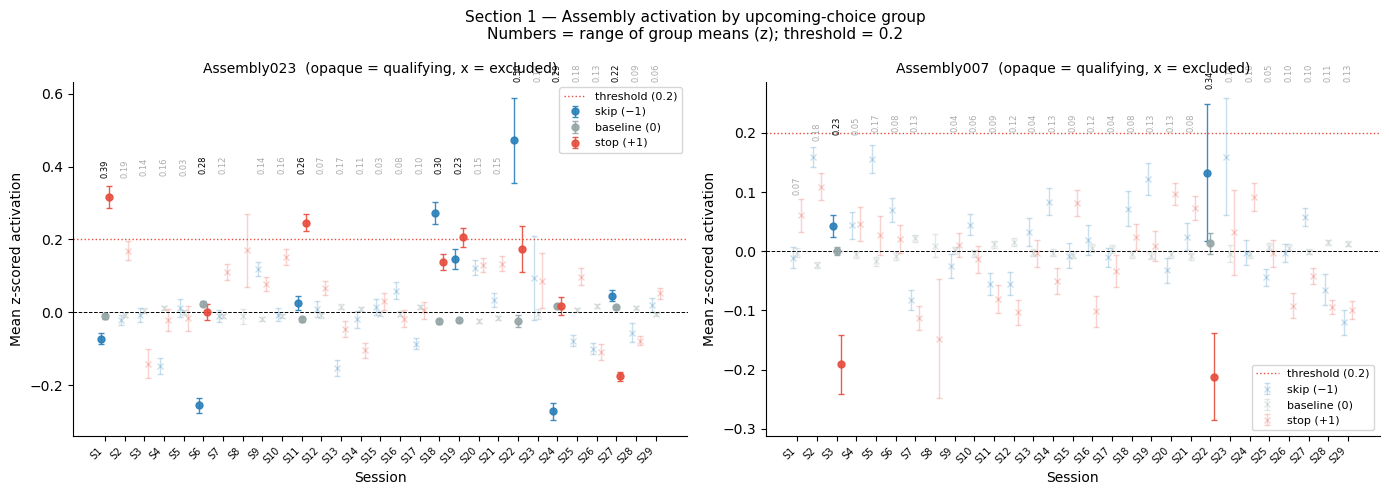

Saved fig1_session_filter


In [55]:
# Per-session mean activation by choice group — qualifying sessions highlighted
fig_s1, axes_s1 = plt.subplots(1, len(TARGET_ASSEMBLIES),
                                figsize=(7 * len(TARGET_ASSEMBLIES), 5))
CHOICE_COLORS = {-1: '#2980b9', 0: '#95a5a6', 1: '#e74c3c'}
CHOICE_LABELS = {-1: 'skip (−1)', 0: 'baseline (0)', 1: 'stop (+1)'}
OFFSETS       = {-1: -0.2, 0: 0.0, 1: 0.2}

for ax, (ens_name, ens_idx) in zip(axes_s1, TARGET_ASSEMBLIES.items()):
    md   = mean_diffs[ens_name]
    qual = set(qualifying_sessions[ens_name])
    y_bot = None
    for s_i, sid in enumerate(session_ids):
        pos       = session_pos[sid]
        y_s       = Y_z[pos, ens_idx].astype(np.float64)
        c_s       = y_choice[pos]
        alpha_dot = 0.9 if s_i in qual else 0.25
        marker    = 'o' if s_i in qual else 'x'
        for g in CHOICE_GROUPS:
            vals = y_s[c_s == g]
            if len(vals) < 2:
                continue
            m   = vals.mean()
            sem = vals.std(ddof=1) / np.sqrt(len(vals))
            eb  = ax.errorbar(s_i + OFFSETS[g], m, yerr=sem, fmt=marker,
                              color=CHOICE_COLORS[g], alpha=alpha_dot,
                              ms=5, capsize=2, lw=1,
                              label=CHOICE_LABELS[g] if s_i == 0 else '')
            if y_bot is None:
                y_bot = m
            y_bot = min(y_bot, m - sem)
        d = md.get(s_i, np.nan)
        if not np.isnan(d):
            ax.text(s_i, ax.get_ylim()[1] if ax.get_ylim()[1] != 0 else 1,
                    f'{d:.2f}', ha='center', va='bottom', fontsize=6,
                    color='k' if s_i in qual else '#aaaaaa', rotation=90)
    ax.axhline(0, color='k', lw=0.7, ls='--')
    ax.axhline(MEAN_DIFF_THRESHOLD, color='#e74c3c', lw=1, ls=':',
               label=f'threshold ({MEAN_DIFF_THRESHOLD})')
    ax.set_xticks(range(len(session_ids)))
    ax.set_xticklabels([f'S{i+1}' for i in range(len(session_ids))],
                       rotation=45, ha='right', fontsize=7)
    ax.set_xlabel('Session', fontsize=10)
    ax.set_ylabel('Mean z-scored activation', fontsize=10)
    ax.set_title(f'{ens_name}  (opaque = qualifying, x = excluded)', fontsize=10)
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Section 1 — Assembly activation by upcoming-choice group\n'
             f'Numbers = range of group means (z); threshold = {MEAN_DIFF_THRESHOLD}',
             fontsize=11)
plt.tight_layout()
for ext in ['png', 'svg']:
    plt.savefig(OUT_DIR / f'{PREFIX}fig1_session_filter.{ext}',
                dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig1_session_filter')


## Section 2 — Feature Inventory and Global Permutation Importance

**Question:** Which behavioral features best predict each target assembly, and what should the behavioral control set be?

**Algorithm:** Permutation importance = mean R² drop when a feature is randomly shuffled (Breiman 2001). Computed from `importance_matrix[session, assembly, feature]`, averaged over **qualifying sessions only** for each target assembly. This avoids diluting the signal with near-zero R² sessions.

**Output:** `ctrl_feat_names_per_assembly`, `ctrl_feat_idx_per_assembly` — the behavioral control set for each assembly (excluding all `upcoming_choice_*` columns).


In [56]:
ctrl_feat_names_per_assembly = {}
ctrl_feat_idx_per_assembly   = {}

print("FEATURE IMPORTANCE — qualifying sessions only")
print("=" * 65)

for ens_name, ens_idx in TARGET_ASSEMBLIES.items():
    qual_idx = qualifying_sessions[ens_name]
    # importance_matrix: (29, 23, 26)
    imp_qual = importance_matrix[qual_idx, ens_idx, :]   # (n_qual, 26)
    feat_mean = np.nanmean(imp_qual, axis=0)             # (26,)
    feat_sem  = np.nanstd(imp_qual, axis=0) / np.sqrt(max(1, len(qual_idx)))
    order     = np.argsort(feat_mean)[::-1]

    print(f"\n{ens_name}  (N_qual={len(qual_idx)} sessions)")
    print(f"  {'Feature':<45}  {'Mean R2 drop':>12}  {'SEM':>8}")
    print("  " + "-" * 70)
    for i in order:
        flag = " *** choice (excluded)" if 'upcoming_choice' in ALL_FEAT_COLS[i] else ""
        print(f"  {ALL_FEAT_COLS[i]:<45}  {feat_mean[i]:>12.5f}  {feat_sem[i]:>8.5f}{flag}")

    ctrl_mask = (feat_mean > IMPORTANCE_THRESHOLD) &                 np.array(['upcoming_choice' not in c for c in ALL_FEAT_COLS])
    ctrl_idx  = np.where(ctrl_mask)[0].tolist()
    ctrl_names = [ALL_FEAT_COLS[i] for i in ctrl_idx]
    ctrl_feat_names_per_assembly[ens_name] = ctrl_names
    ctrl_feat_idx_per_assembly[ens_name]   = ctrl_idx
    print(f"  -> Control features (threshold={IMPORTANCE_THRESHOLD}): {ctrl_names}")


FEATURE IMPORTANCE — qualifying sessions only

Assembly023  (N_qual=8 sessions)
  Feature                                        Mean R2 drop       SEM
  ----------------------------------------------------------------------
  head_angle                                          0.07912   0.01291
  frame_raw_500msMedian                               0.03029   0.00545
  lick_detected_1                                     0.02824   0.01110
  frame_YawPitch_abs_vel_sum_500msMedian              0.01811   0.00446
  head_angle_vel                                      0.01476   0.00329
  frame_raw_abs_acc_500msMedian                       0.00901   0.00275
  movement_energy_smooth5                             0.00528   0.00131
  track_zone_int_0                                    0.00504   0.00271
  track_zone_int_6                                    0.00325   0.00056
  reward_window_1                                     0.00301   0.00110
  track_zone_int_4                                    0

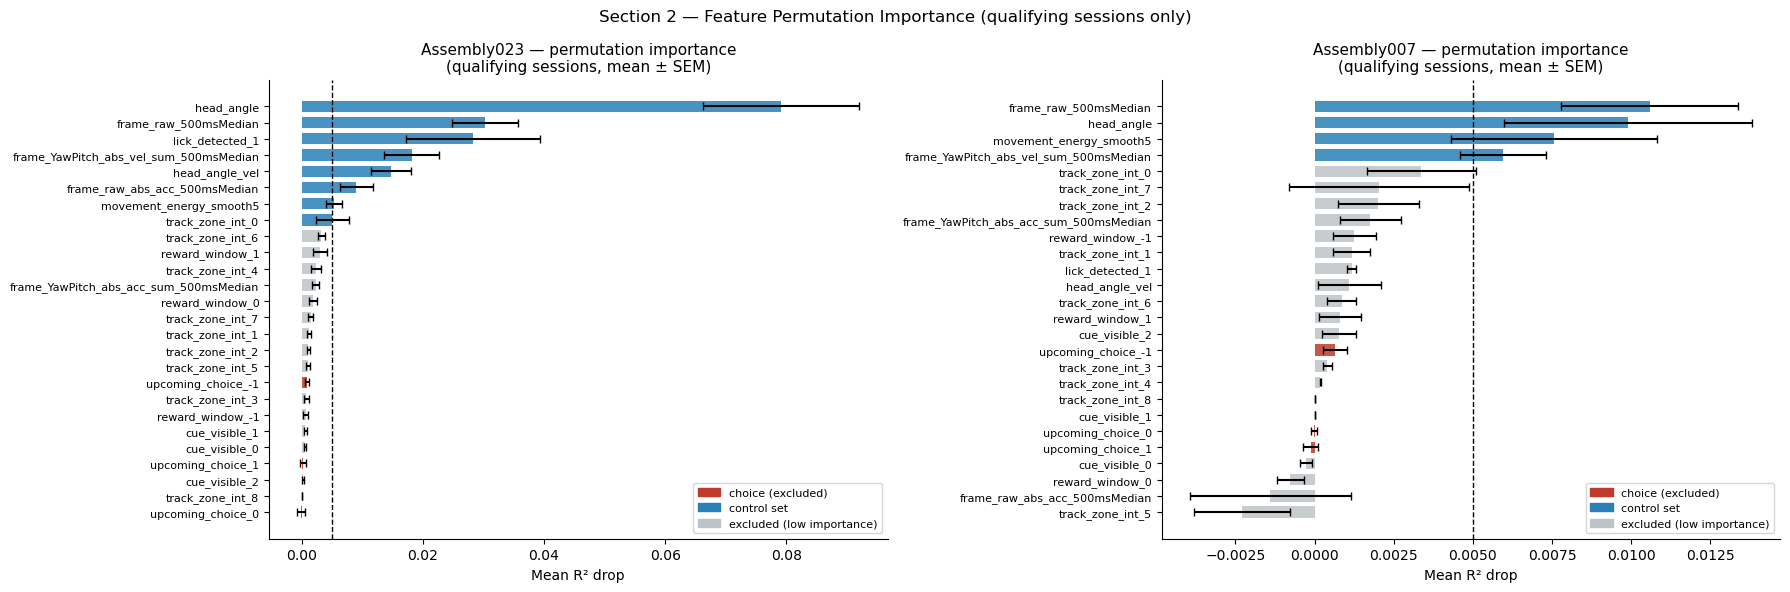

Saved fig2_feature_importance.png/svg


In [57]:
fig11, axes11 = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

for ax, (ens_name, ens_idx) in zip(axes11, TARGET_ASSEMBLIES.items()):
    qual_idx  = qualifying_sessions[ens_name]
    imp_qual  = importance_matrix[qual_idx, ens_idx, :]
    feat_mean = np.nanmean(imp_qual, axis=0)
    feat_sem  = np.nanstd(imp_qual, axis=0) / np.sqrt(max(1, len(qual_idx)))
    order     = np.argsort(feat_mean)[::-1]

    ctrl_set  = set(ctrl_feat_names_per_assembly[ens_name])
    colors    = ['#c0392b' if 'upcoming_choice' in ALL_FEAT_COLS[i] else
                 ('#2980b9' if ALL_FEAT_COLS[i] in ctrl_set else '#bdc3c7')
                 for i in order]
    y_pos     = np.arange(len(order))
    ax.barh(y_pos, feat_mean[order], xerr=feat_sem[order], color=colors,
            alpha=0.85, capsize=3, height=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([ALL_FEAT_COLS[i] for i in order], fontsize=8)
    ax.invert_yaxis()
    ax.axvline(IMPORTANCE_THRESHOLD, color='k', lw=1, ls='--', label=f'threshold={IMPORTANCE_THRESHOLD}')
    ax.set_title(f'{ens_name} — permutation importance\n(qualifying sessions, mean ± SEM)', fontsize=11)
    ax.set_xlabel('Mean R² drop', fontsize=10)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='#c0392b', label='choice (excluded)'),
                        Patch(color='#2980b9', label='control set'),
                        Patch(color='#bdc3c7', label='excluded (low importance)')],
              fontsize=8, loc='lower right')

plt.suptitle('Section 2 — Feature Permutation Importance (qualifying sessions only)', fontsize=12)
plt.tight_layout()
for ext in ['png', 'svg']:
    plt.savefig(OUT_DIR / f'{PREFIX}fig2_feature_importance.{ext}', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig2_feature_importance.png/svg")


## Section 3 — GLM Sanity Check (Primary Test)

**Question:** Do `upcoming_choice` and `cue_visible` have statistically significant linear coefficients in the assembly z-score after controlling for all other features?

**Algorithm:** Per qualifying session, OLS regression `y_assembly_z ~ X_glm` where
`X_glm` is the 22-column design matrix: `ALL_FEAT_COLS` minus one reference category
per one-hot group (`upcoming_choice_0`, `cue_visible_0`, `track_zone_int_0`,
`reward_window_0`). Dropping references makes the design matrix full-rank and gives
coefficients interpretable as contrasts against the reference level. Intercept added
via `statsmodels.add_constant`. Aggregate with one-sample t-test against 0; Bonferroni-
correct over 4 choice/cue contrasts × 2 assemblies = 8 tests (α = 0.05/8; Dunn 1961).

**New in v2:** Temporal sequence plot — coefficient vs session index, slope t-test —
directly tests the sign-flip hypothesis for E07.

**Output:** `glm_coef_df` (per-session), `glm_agg_df` (aggregate + Bonferroni flags).


In [84]:
from scipy.stats import ttest_1samp as _t1s
from scipy.stats import linregress  as _linreg

BONFERRONI_N = len(GLM_CHOICE_CUE_COLS) * len(TARGET_ASSEMBLIES)   # 4 * 2 = 8
ALPHA_BONF   = 0.05 / BONFERRONI_N

glm_coef_rows = []
for ens_name in TARGET_ASSEMBLIES:
    for s_i in qualifying_sessions[ens_name]:
        sid   = session_ids[s_i]
        pos   = session_pos[sid]
        X_s   = X_z[pos][:, GLM_FEAT_IDX].astype(np.float64)
        y_s   = Y_z[pos, TARGET_ASSEMBLIES[ens_name]].astype(np.float64)
        valid = ~np.isnan(X_s).any(axis=1) & ~np.isnan(y_s)
        X_s, y_s = X_s[valid], y_s[valid]
        col_names = ['const'] + GLM_FEAT_COLS
        try:
            fit = sm.OLS(y_s, sm.add_constant(X_s, has_constant='add')).fit()
        except Exception as e:
            log.warning(f"GLM failed {ens_name}/S{s_i+1}: {e}"); continue
        for col in GLM_CHOICE_CUE_COLS:
            ci = col_names.index(col)
            glm_coef_rows.append(dict(
                assembly=ens_name, session_idx=s_i, session_id=sid, feature=col,
                coef=fit.params[ci], se=fit.bse[ci],
                tstat=fit.tvalues[ci], pval=fit.pvalues[ci],
                glm_r2=fit.rsquared,
            ))

glm_coef_df = pd.DataFrame(glm_coef_rows)
glm_coef_df.to_csv(OUT_DIR / f'{PREFIX}glm_coef_per_session.csv', index=False)
print(f"Saved {len(glm_coef_df)} rows → {PREFIX}glm_coef_per_session.csv")

# Aggregate
glm_agg_rows = []
for ens_name in TARGET_ASSEMBLIES:
    for feat in CHOICE_CUE_COLS:
        sub = glm_coef_df[(glm_coef_df.assembly==ens_name) & (glm_coef_df.feature==feat)]
        if len(sub) < 2: continue
        coefs = sub.coef.values
        t, p  = _t1s(coefs, 0.0)
        glm_agg_rows.append(dict(
            assembly=ens_name, feature=feat, n_sessions=len(coefs),
            mean_coef=float(np.mean(coefs)), sem=float(np.std(coefs,ddof=1)/np.sqrt(len(coefs))),
            tstat=float(t), p_raw=float(p), bonf_sig=(float(p) < ALPHA_BONF),
            ci_lo=float(np.mean(coefs) - 1.96*np.std(coefs,ddof=1)/np.sqrt(len(coefs))),
            ci_hi=float(np.mean(coefs) + 1.96*np.std(coefs,ddof=1)/np.sqrt(len(coefs))),
        ))

glm_agg_df = pd.DataFrame(glm_agg_rows)
glm_agg_df.to_csv(OUT_DIR / f'{PREFIX}glm_agg.csv', index=False)

print(f"\nGLM AGGREGATE — Bonferroni alpha = 0.05/{BONFERRONI_N} = {ALPHA_BONF:.4f}")
print(f"\n{'Assembly':<12} {'Feature':<24} {'N':>3} {'Mean':>9} {'SEM':>7} {'t':>6} {'p-raw':>9} {'Bonf?':>7}")
print("-" * 78)
for _, r in glm_agg_df.iterrows():
    sig = "YES **" if r.bonf_sig else "no"
    print(f"{r.assembly:<12} {r.feature:<24} {int(r.n_sessions):>3} {r.mean_coef:>+9.4f} "
          f"{r.sem} {r.tstat:>6.2f} {r.p_raw:>9.5f} {sig:>7}")


Saved 40 rows → v2_glm_coef_per_session.csv

GLM AGGREGATE — Bonferroni alpha = 0.05/8 = 0.0063

Assembly     Feature                    N      Mean     SEM      t     p-raw   Bonf?
------------------------------------------------------------------------------
Assembly023  cue_visible_1              8   +0.1192 <bound method Series.sem of assembly        Assembly023
feature       cue_visible_1
n_sessions                8
mean_coef           0.11915
sem                0.041691
tstat              2.857915
p_raw               0.02441
bonf_sig              False
ci_lo              0.037435
ci_hi              0.200865
Name: 0, dtype: object>   2.86   0.02441      no
Assembly023  cue_visible_2              8   +0.0289 <bound method Series.sem of assembly        Assembly023
feature       cue_visible_2
n_sessions                8
mean_coef          0.028931
sem                0.025009
tstat                1.1568
p_raw              0.285301
bonf_sig              False
ci_lo             -0.02008

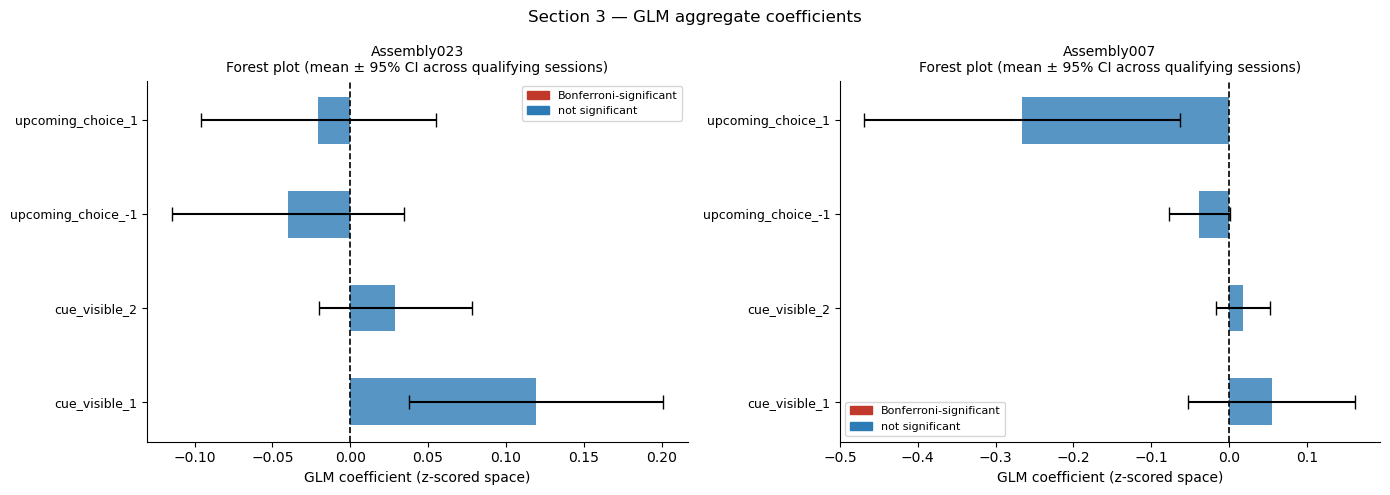

Saved fig3a_glm_forest


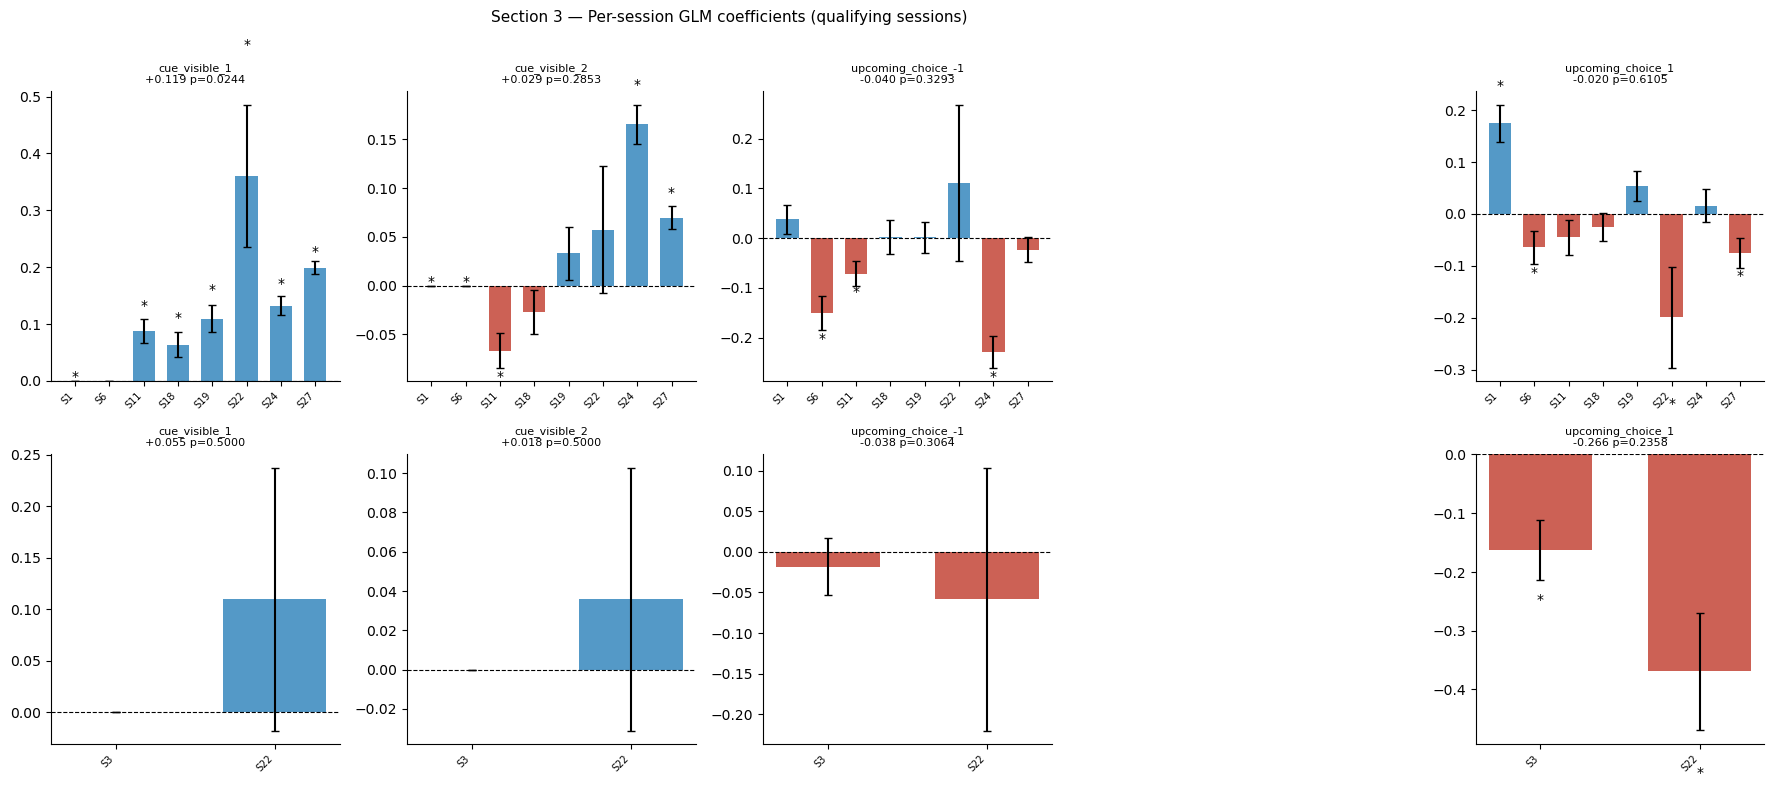

Saved fig3b_glm_session_bars


In [85]:
# Forest plot: aggregate mean ± 95% CI, red if Bonferroni-significant
fig14, axes14 = plt.subplots(1, 2, figsize=(14, 5))
for ax, ens_name in zip(axes14, TARGET_ASSEMBLIES):
    sub = glm_agg_df[glm_agg_df.assembly == ens_name].reset_index(drop=True)
    y   = np.arange(len(sub))
    ci_lo = sub.mean_coef - sub.ci_lo
    ci_hi = sub.ci_hi - sub.mean_coef
    colors = ['#c0392b' if r.bonf_sig else '#2c7bb6' for _, r in sub.iterrows()]
    ax.barh(y, sub.mean_coef, xerr=[ci_lo, ci_hi], color=colors, alpha=0.8,
            height=0.5, capsize=5)
    ax.axvline(0, color='k', lw=1.2, ls='--')
    ax.set_yticks(y)
    ax.set_yticklabels(sub.feature, fontsize=9)
    ax.set_xlabel('GLM coefficient (z-scored space)', fontsize=10)
    ax.set_title(f'{ens_name}\nForest plot (mean ± 95% CI across qualifying sessions)', fontsize=10)
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='#c0392b', label='Bonferroni-significant'),
                        Patch(color='#2c7bb6', label='not significant')], fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
plt.suptitle('Section 3 — GLM aggregate coefficients', fontsize=12)
plt.tight_layout()
for ext in ['png', 'svg']:
    plt.savefig(OUT_DIR / f'{PREFIX}fig3a_glm_forest.{ext}', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig3a_glm_forest")

# Per-session bar grid
fig14b, axes14b = plt.subplots(
    len(TARGET_ASSEMBLIES), len(CHOICE_CUE_COLS),
    figsize=(3.5*len(CHOICE_CUE_COLS), 4*len(TARGET_ASSEMBLIES)), squeeze=False)

for row_i, ens_name in enumerate(TARGET_ASSEMBLIES):
    for col_i, feat in enumerate(CHOICE_CUE_COLS):
        ax  = axes14b[row_i, col_i]
        sub = (glm_coef_df[(glm_coef_df.assembly==ens_name)&(glm_coef_df.feature==feat)]
               .sort_values('session_idx').reset_index(drop=True))
        agg = glm_agg_df[(glm_agg_df.assembly==ens_name)&(glm_agg_df.feature==feat)]
        if sub.empty: ax.set_visible(False); continue
        x = np.arange(len(sub))
        ax.bar(x, sub.coef, color=['#2980b9' if v>=0 else '#c0392b' for v in sub.coef],
               alpha=0.8, width=0.65)
        ax.errorbar(x, sub.coef, yerr=sub.se, fmt='none', color='k', lw=1.5, capsize=3)
        for xi, row in sub.iterrows():
            if row.pval < 0.05:
                ax.text(xi, row.coef + np.sign(row.coef)*row.se*1.8,
                        '*', ha='center', fontsize=10)
        ax.axhline(0, color='k', lw=0.8, ls='--')
        ax.set_xticks(x)
        ax.set_xticklabels([f"S{sub.session_idx.iloc[j]+1}" for j in range(len(sub))],
                           rotation=45, ha='right', fontsize=7)
        ax.spines[['top','right']].set_visible(False)
        if not agg.empty:
            ar = agg.iloc[0]
            p_s = f"p={ar.p_raw:.4f}" + (" **" if ar.bonf_sig else "")
            ax.set_title(f"{feat}\n{ar.mean_coef:+.3f} {p_s}", fontsize=8)
        if col_i == 0: ax.set_ylabel(f'{ens_name}\nGLM coef', fontsize=8)

plt.suptitle('Section 3 — Per-session GLM coefficients (qualifying sessions)', fontsize=11)
plt.tight_layout()
for ext in ['png', 'svg']:
    plt.savefig(OUT_DIR / f'{PREFIX}fig3b_glm_session_bars.{ext}', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig3b_glm_session_bars")


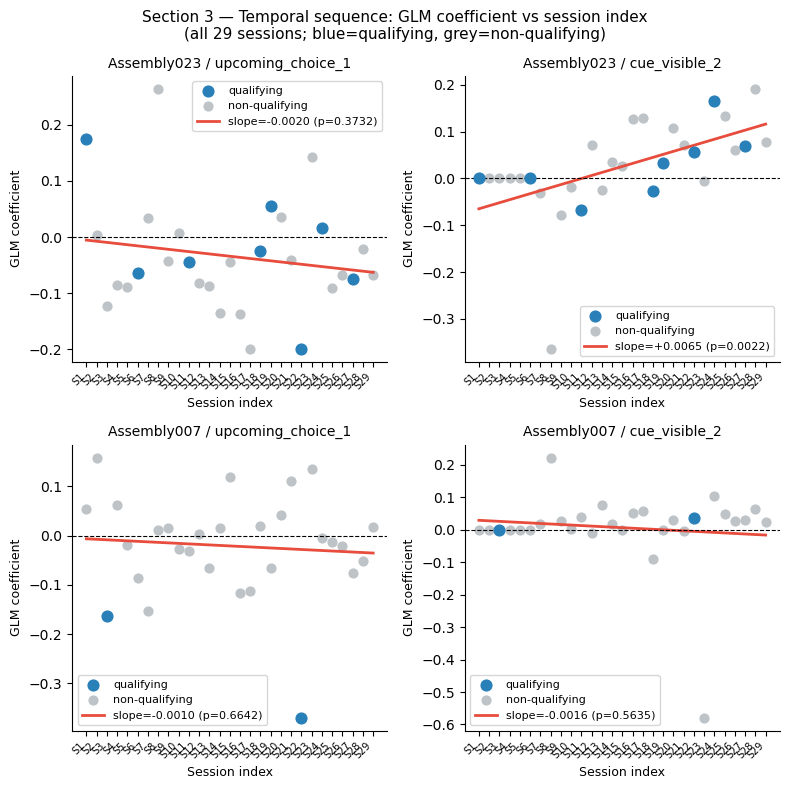

Saved fig3c_glm_temporal


In [86]:
# Temporal sequence: coefficient vs session index — tests sign-flip hypothesis.
# Uses ALL 29 sessions (not just qualifying) to show the full picture.
# Per assembly, fit OLS GLM for every session, extract coefficient.

TEMPORAL_FEATS = ['upcoming_choice_1', 'cue_visible_2']

temporal_coef = {en: {f: [] for f in TEMPORAL_FEATS} for en in TARGET_ASSEMBLIES}
col_names_c   = ['const'] + GLM_FEAT_COLS

for ens_name, ens_idx in TARGET_ASSEMBLIES.items():
    for s_i, sid in enumerate(session_ids):
        pos = session_pos[sid]
        X_s = X_z[pos][:, GLM_FEAT_IDX].astype(np.float64)
        y_s = Y_z[pos, ens_idx].astype(np.float64)
        valid = ~np.isnan(X_s).any(axis=1) & ~np.isnan(y_s)
        X_s, y_s = X_s[valid], y_s[valid]
        try:
            fit = sm.OLS(y_s, sm.add_constant(X_s, has_constant='add')).fit()
        except Exception:
            for f in TEMPORAL_FEATS:
                temporal_coef[ens_name][f].append(np.nan)
            continue
        for feat in TEMPORAL_FEATS:
            ci = col_names_c.index(feat)
            temporal_coef[ens_name][feat].append(float(fit.params[ci]))

# Slope test and figure
fig15, axes15 = plt.subplots(len(TARGET_ASSEMBLIES), len(TEMPORAL_FEATS),
                              figsize=(8, 4*len(TARGET_ASSEMBLIES)), squeeze=False)

x_idx = np.arange(len(session_ids))
qual_markers = {en: set(qualifying_sessions[en]) for en in TARGET_ASSEMBLIES}

for row_i, ens_name in enumerate(TARGET_ASSEMBLIES):
    for col_i, feat in enumerate(TEMPORAL_FEATS):
        ax   = axes15[row_i, col_i]
        coefs = np.array(temporal_coef[ens_name][feat])
        valid = ~np.isnan(coefs)
        x_v, y_v = x_idx[valid], coefs[valid]

        # Color by qualifying vs non-qualifying
        is_qual = np.array([i in qual_markers[ens_name] for i in x_idx])
        ax.scatter(x_idx[is_qual & valid],  coefs[is_qual & valid],
                   color='#2980b9', s=60, zorder=3, label='qualifying')
        ax.scatter(x_idx[~is_qual & valid], coefs[~is_qual & valid],
                   color='#bdc3c7', s=40, zorder=2, label='non-qualifying')

        # Fit and test slope
        if len(x_v) >= 3:
            slope, intercept, r_val, p_slope, se_slope = scipy_stats.linregress(x_v, y_v)
            ax.plot(x_v, slope*x_v + intercept, '-', color='#e74c3c', lw=2,
                    label=f'slope={slope:+.4f} (p={p_slope:.4f})')
        ax.axhline(0, color='k', lw=0.8, ls='--')
        ax.set_xticks(x_idx[valid])
        ax.set_xticklabels([f'S{i+1}' for i in x_idx[valid]],
                           rotation=45, ha='right', fontsize=7)
        ax.set_title(f'{ens_name} / {feat}', fontsize=10)
        ax.set_ylabel('GLM coefficient', fontsize=9)
        ax.set_xlabel('Session index', fontsize=9)
        ax.legend(fontsize=8)
        ax.spines[['top','right']].set_visible(False)

plt.suptitle('Section 3 — Temporal sequence: GLM coefficient vs session index\n'
             '(all 29 sessions; blue=qualifying, grey=non-qualifying)', fontsize=11)
plt.tight_layout()
for ext in ['png', 'svg']:
    plt.savefig(OUT_DIR / f'{PREFIX}fig3c_glm_temporal.{ext}', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig3c_glm_temporal")


## Section 4 — MLP-Residual Computation (Core Methodological Upgrade)

**Question:** What variance in assembly activity is unexplained by the trained encoding model?

**Algorithm:** Per-session prediction with the median-over-seeds MLP checkpoint (5 seeds × 29 sessions; 2-layer MLP, hidden=64, ReLU). Inputs: cached z-scored features `X_z`. Output: z-scored prediction `y_pred_z`. Residual = `y_actual_z − y_pred_z` (Lopes-dos-Santos et al. 2013 assembly baseline; MLP nonlinear extension).

For comparison, a **Ridge baseline residual** in the same z-scored cache space (Ridge α=1.0, Hoerl & Kennard 1970) is also computed. This is the cache-consistent equivalent of the v1 Ridge residualization.

**Output:** `mlp_predictions[name]`, `mlp_residuals[name]`, `ridge_residuals_z[name]`.


In [61]:
mlp_predictions  = {}
mlp_residuals    = {}
mlp_r2_all_frames = {}   # R² on ALL frames (train+test) — for residual computation
mlp_r2_test       = {}   # R² on held-out TEST frames   — matches all_r2.npy

for ens_name, ens_idx in TARGET_ASSEMBLIES.items():
    _pred_path = OUT_DIR / f'{PREFIX}mlp_predictions_{ens_name}.npy'
    if _pred_path.exists():
        pred = np.load(_pred_path)
        log.info(f'Loaded cached MLP predictions for {ens_name}')
    else:
        log.info(f'Computing MLP predictions for {ens_name}...')
        pred = load_mlp_predictions(ens_idx)
        np.save(_pred_path, pred)
    mlp_predictions[ens_name] = pred
    mlp_residuals[ens_name]   = Y_z[:, ens_idx] - pred

    # ── All-frame R² (biased — includes training data) ─────────────────
    r2_all = {}
    y_actual = Y_z[:, ens_idx]
    for s_i, sid in enumerate(session_ids):
        pos   = session_pos[sid]
        yp, ya = pred[pos], y_actual[pos]
        valid  = ~np.isnan(yp)
        if valid.sum() < 5:
            r2_all[sid] = np.nan; continue
        ss_r = np.sum((ya[valid] - yp[valid])**2)
        ss_t = np.sum((ya[valid] - ya[valid].mean())**2) + 1e-12
        r2_all[sid] = float(1 - ss_r / ss_t)
    mlp_r2_all_frames[ens_name] = r2_all

    # ── Test-split R² (matches all_r2.npy) ────────────────────────────
    _tr2_path = OUT_DIR / f'{PREFIX}test_r2_{ens_name}.npy'
    if _tr2_path.exists():
        r2_seeds = np.load(_tr2_path)   # (n_seeds, n_sessions)
        log.info(f'Loaded cached test-split R² for {ens_name}')
    else:
        log.info(f'Computing test-split R² for {ens_name} (5 seeds × 29 sessions)...')
        r2_seeds = compute_test_r2(ens_idx)
        np.save(_tr2_path, r2_seeds)
    r2_test_mean = np.nanmean(r2_seeds, axis=0)   # (n_sessions,) — should match mean_r2[:, ens_idx]
    r2_test = {session_ids[i]: float(r2_test_mean[i]) for i in range(len(session_ids))}
    mlp_r2_test[ens_name] = r2_test

    # ── Comparison: test R² vs all_r2.npy ─────────────────────────────
    expected = mean_r2[:, ens_idx]   # (n_sessions,)
    mismatches = []
    for s_i, sid in enumerate(session_ids):
        got, exp = r2_test_mean[s_i], expected[s_i]
        if not np.isnan(got) and not np.isnan(exp) and abs(got - exp) > 0.05:
            mismatches.append((s_i+1, got, exp))
    if mismatches:
        for sn, got, exp in mismatches:
            log.warning(f'{ens_name} S{sn}: test R2={got:.4f} vs all_r2={exp:.4f}')
    else:
        log.info(f'{ens_name}: test R² matches all_r2.npy (max diff '
                 f'{np.nanmax(np.abs(r2_test_mean - expected)):.4f})')

    log.info(f'{ens_name}: mean test R2={np.nanmean(r2_test_mean):.4f}  '
             f'mean all-frame R2={np.nanmean(list(r2_all.values())):.4f}')

print('MLP predictions and residuals computed.')
for ens_name in TARGET_ASSEMBLIES:
    for sid in list(session_ids)[:3]:
        pos = session_pos[sid]
        m   = np.nanmean(mlp_residuals[ens_name][pos])
        assert abs(m) < 0.5, f'Residual mean too large: {ens_name}/{sid} mean={m:.3f}'
print('Residual mean checks passed (|mean| < 0.5 per session).')


INFO: Loaded cached MLP predictions for Assembly023
INFO: Computing test-split R² for Assembly023 (5 seeds × 29 sessions)...
INFO: Assembly023: test R² matches all_r2.npy (max diff 0.0000)
INFO: Assembly023: mean test R2=0.0459  mean all-frame R2=0.0959
INFO: Loaded cached MLP predictions for Assembly007
INFO: Computing test-split R² for Assembly007 (5 seeds × 29 sessions)...
INFO: Assembly007: test R² matches all_r2.npy (max diff 0.0000)
INFO: Assembly007: mean test R2=-0.0039  mean all-frame R2=0.0481


MLP predictions and residuals computed.
Residual mean checks passed (|mean| < 0.5 per session).


INFO: Assembly023 Ridge: mean R2=0.0368
INFO: Assembly007 Ridge: mean R2=0.0087


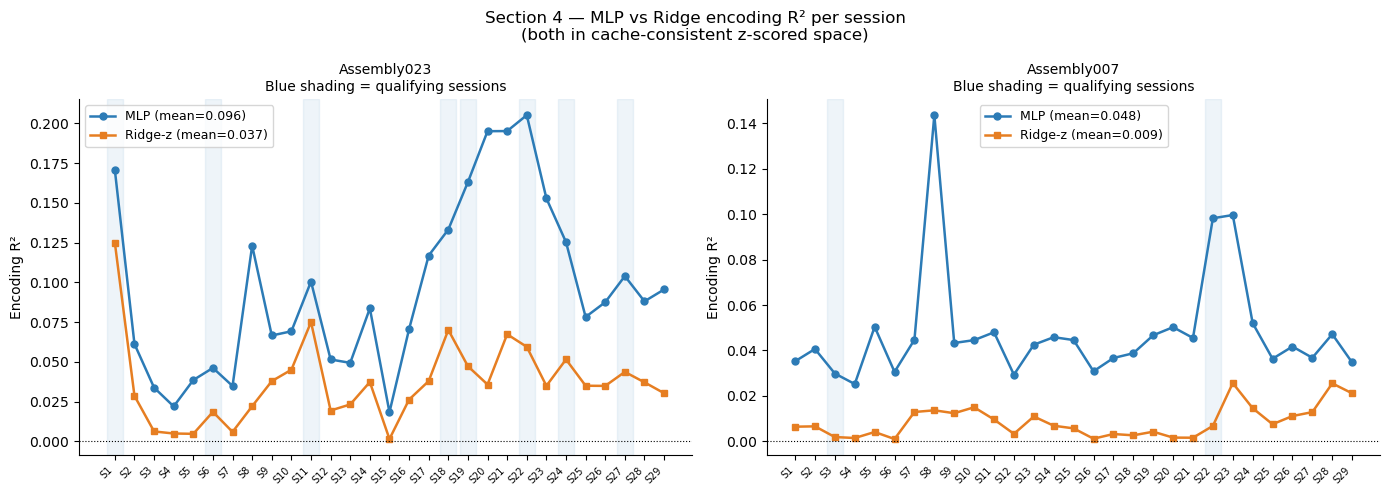

Saved fig4_r2_comparison


In [62]:
ridge_residuals_z = {}
ridge_r2_per_sess = {}

for ens_name in TARGET_ASSEMBLIES:
    ctrl_idx = ctrl_feat_idx_per_assembly[ens_name]
    resid, r2s = ridge_residuals_per_session(ens_name, ctrl_feat_idx=ctrl_idx)
    ridge_residuals_z[ens_name] = resid
    ridge_r2_per_sess[ens_name] = r2s
    log.info(f"{ens_name} Ridge: mean R2={np.nanmean(list(r2s.values())):.4f}")

# Figure: per-session R2 comparison (MLP vs Ridge-z)
fig18, axes18 = plt.subplots(1, 2, figsize=(14, 5))
x_sess = np.arange(len(session_ids))

for ax, ens_name in zip(axes18, TARGET_ASSEMBLIES):
    mlp_r2v   = [mlp_r2_per_sess[ens_name].get(s, np.nan)   for s in session_ids]
    ridge_r2v = [ridge_r2_per_sess[ens_name].get(s, np.nan) for s in session_ids]
    mlp_r2v   = np.array(mlp_r2v);   ridge_r2v = np.array(ridge_r2v)

    ax.plot(x_sess, mlp_r2v,   '-o', color='#2c7bb6', lw=1.8, ms=5,
            label=f'MLP (mean={np.nanmean(mlp_r2v):.3f})')
    ax.plot(x_sess, ridge_r2v, '-s', color='#e67e22', lw=1.8, ms=5,
            label=f'Ridge-z (mean={np.nanmean(ridge_r2v):.3f})')

    # Mark qualifying sessions
    for qi in qualifying_sessions[ens_name]:
        ax.axvspan(qi - 0.4, qi + 0.4, color='#2c7bb6', alpha=0.08)

    ax.axhline(0, color='k', lw=0.8, ls=':')
    ax.set_xticks(x_sess)
    ax.set_xticklabels([f'S{i+1}' for i in range(len(session_ids))],
                       rotation=45, ha='right', fontsize=7)
    ax.set_title(f'{ens_name}\nBlue shading = qualifying sessions', fontsize=10)
    ax.set_ylabel('Encoding R²', fontsize=10)
    ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)

plt.suptitle('Section 4 — MLP vs Ridge encoding R² per session\n'
             '(both in cache-consistent z-scored space)', fontsize=12)
plt.tight_layout()
for ext in ['png', 'svg']:
    plt.savefig(OUT_DIR / f'{PREFIX}fig4_r2_comparison.{ext}', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig4_r2_comparison")


## Section 5 — Variance Partitioning in Cached Space

**Question:** What fraction of assembly variance is *uniquely* explained by `upcoming_choice`/`cue_visible` after partialling out the behavioral control set?

**Algorithm:** Commonality analysis (Mood 1969). Per qualifying session, fit three Ridge models (`R²_full`, `R²_ctrl_only`, `R²_target_only`) and decompose: `unique_target = R²_full − R²_ctrl_only`, `shared = R²_ctrl + R²_target − R²_full` (Hoerl & Kennard 1970 for Ridge). All inputs: z-scored from training cache.

**Output:** `vp_results[ens_name][contrast]` — list of per-qualifying-session variance partition dicts.


In [63]:
CHOICE_IDX  = [ALL_FEAT_COLS.index(c) for c in ALL_FEAT_COLS
               if 'upcoming_choice' in c and c not in GLM_DROP_COLS]  # excl. _0 ref
CUE_IDX     = [ALL_FEAT_COLS.index(c) for c in ALL_FEAT_COLS
               if 'cue_visible' in c and c not in GLM_DROP_COLS]      # excl. _0 ref

vp_results = {}
for ens_name, ens_idx in TARGET_ASSEMBLIES.items():
    vp_results[ens_name] = {'choice': [], 'cue': []}
    ctrl_idx = ctrl_feat_idx_per_assembly[ens_name]
    for s_i in qualifying_sessions[ens_name]:
        sid  = session_ids[s_i]
        pos  = session_pos[sid]
        y_s  = Y_z[pos, ens_idx].astype(np.float64)
        X_c  = X_z[pos][:, ctrl_idx].astype(np.float64)
        for label, feat_idx in [('choice', CHOICE_IDX), ('cue', CUE_IDX)]:
            X_t = X_z[pos][:, feat_idx].astype(np.float64)
            vp_results[ens_name][label].append(
                variance_partition_session(y_s, X_c, X_t))
    log.info(f"{ens_name}: variance partitioning done ({len(qualifying_sessions[ens_name])} sessions)")

COMPS = ['unique_ctrl', 'shared', 'unique_target', 'unexplained']
print("\nVARIANCE PARTITIONING — qualifying sessions mean")
print(f"{'Assembly':<12} {'Contrast':<8} {'unique_target':>14} {'shared':>10} "
      f"{'unique_ctrl':>12} {'unexplained':>12}")
print("-" * 62)
for ens_name in TARGET_ASSEMBLIES:
    for contrast in ['choice', 'cue']:
        vp_list = vp_results[ens_name][contrast]
        m = {k: np.nanmean([v[k] for v in vp_list]) for k in COMPS}
        print(f"{ens_name:<12} {contrast:<8} {m['unique_target']:>14.5f} "
              f"{m['shared']:>10.5f} {m['unique_ctrl']:>12.5f} {m['unexplained']:>12.5f}")


INFO: Assembly023: variance partitioning done (8 sessions)
INFO: Assembly007: variance partitioning done (2 sessions)



VARIANCE PARTITIONING — qualifying sessions mean
Assembly     Contrast  unique_target     shared  unique_ctrl  unexplained
--------------------------------------------------------------
Assembly023  choice          0.00123    0.00374      0.05760      0.93743
Assembly023  cue             0.00154    0.00171      0.05962      0.93712
Assembly007  choice          0.00165    0.00066      0.00366      0.99403
Assembly007  cue             0.00001    0.00008      0.00424      0.99567


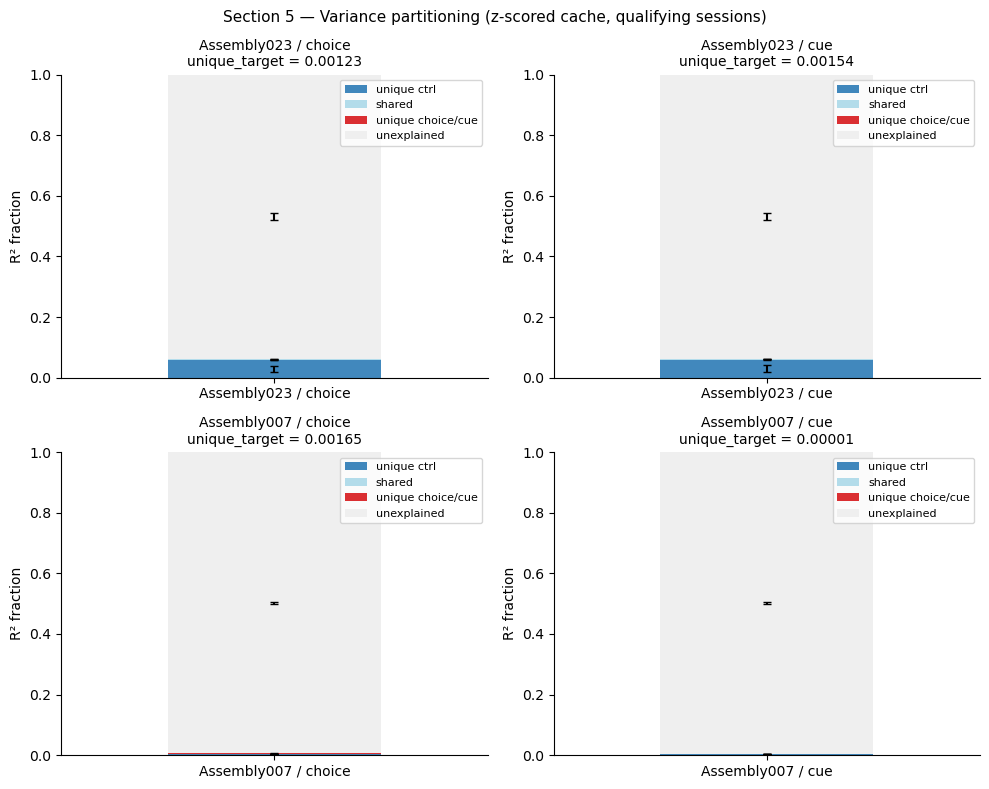

Saved fig5_variance_partition


In [64]:
VP_COLORS = {'unique_ctrl':'#2c7bb6','shared':'#abd9e9','unique_target':'#d7191c','unexplained':'#eeeeee'}
COMP_LABELS = {'unique_ctrl':'unique ctrl','shared':'shared','unique_target':'unique choice/cue','unexplained':'unexplained'}

fig21, axes21 = plt.subplots(2, 2, figsize=(10, 8))

for row_i, ens_name in enumerate(TARGET_ASSEMBLIES):
    for col_i, contrast in enumerate(['choice', 'cue']):
        ax = axes21[row_i, col_i]
        vp_list = vp_results[ens_name][contrast]
        means = {k: np.nanmean([v[k] for v in vp_list]) for k in COMPS}
        sems  = {k: np.nanstd([v[k] for v in vp_list], ddof=1)/np.sqrt(len(vp_list))
                 for k in COMPS}
        bottom = 0.0
        for comp in COMPS:
            ax.bar([0], [means[comp]], bottom=[bottom], width=0.5,
                   color=VP_COLORS[comp], label=COMP_LABELS[comp], alpha=0.9)
            mid = bottom + means[comp]/2
            ax.errorbar([0], [mid], yerr=[sems[comp]], fmt='none', color='k',
                        capsize=3, lw=1.5)
            bottom += means[comp]
        ax.set_xlim(-0.5, 0.5); ax.set_xticks([0])
        ax.set_xticklabels([f'{ens_name} / {contrast}'], fontsize=10)
        ax.set_ylabel('R² fraction', fontsize=10); ax.set_ylim(0, 1)
        ax.set_title(f'{ens_name} / {contrast}\n' +
                     f'unique_target = {means["unique_target"]:.5f}', fontsize=10)
        ax.legend(fontsize=8, loc='upper right')
        ax.spines[['top','right']].set_visible(False)

plt.suptitle('Section 5 — Variance partitioning (z-scored cache, qualifying sessions)', fontsize=11)
plt.tight_layout()
for ext in ['png', 'svg']:
    plt.savefig(OUT_DIR / f'{PREFIX}fig5_variance_partition.{ext}', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig5_variance_partition")


## Section 6 — Conditional Permutation Importance

**Question:** Is the near-zero global permutation importance of `upcoming_choice`/`cue_visible` an artifact of collinearity with `head_angle`?

**Algorithm:** Permute the target feature **within head_angle quintile bins** (5 bins). The R² drop in this conditional permutation test isolates unique signal from the collinear confound (Strobl et al. 2008, *Conditional variable importance for random forests*). Global PV is taken from `importance_matrix[qual_sessions, ens_idx, feat_idx]` (mean over qualifying sessions). Ratio = conditional PV / global PV; ratio > 2 → collinearity is masking the signal.

**Output:** `cond_pv_results[ens_name][feat_name]` — list of per-qualifying-session conditional PV values.


In [65]:
N_HA_BINS    = 5
N_COND_PERMS = 200
COND_PV_FEATS = {'upcoming_choice_1': ALL_FEAT_COLS.index('upcoming_choice_1'),
                 'cue_visible_2'    : ALL_FEAT_COLS.index('cue_visible_2')}

def _cond_pv_session(ens_name, s_i, feat_idx, n_bins=N_HA_BINS, n_perms=N_COND_PERMS, seed=42):
    """Conditional PV for one session using seed=42 MLP checkpoint."""
    sid  = session_ids[s_i]
    pos  = session_pos[sid]
    X_s  = X_z[pos].astype(np.float32)
    y_s  = Y_z[pos, TARGET_ASSEMBLIES[ens_name]].astype(np.float32)
    mp   = MLP_ROOT/f'seed{seed}'/f'session_{s_i:02d}_neuron_{TARGET_ASSEMBLIES[ens_name]:02d}.pt'
    if not mp.exists(): return np.nan
    mdl  = _MLP(MLP_INPUT, MLP_HIDDEN, MLP_LAYERS, MLP_OUT)
    mdl.load_state_dict(torch.load(mp, map_location='cpu')); mdl.eval()
    with torch.no_grad():
        _, yb = mdl(torch.tensor(X_s))
    r2_base = float(r2_score(y_s, yb.squeeze(-1).numpy()))
    ha      = X_s[:, HEAD_ANGLE_IDX]
    edges   = np.quantile(ha, np.linspace(0, 1, n_bins+1))
    bids    = np.digitize(ha, edges[1:-1])
    rng_c   = np.random.default_rng(42)
    drops   = []
    for _ in range(n_perms):
        Xp = X_s.copy()
        for b in range(n_bins):
            bmask = (bids == b)
            if bmask.sum() < 2: continue
            bi = np.where(bmask)[0]
            Xp[bmask, feat_idx] = Xp[rng_c.permutation(bi), feat_idx]
        with torch.no_grad():
            _, yp = mdl(torch.tensor(Xp))
        drops.append(r2_base - float(r2_score(y_s, yp.squeeze(-1).numpy())))
    return float(np.mean(drops))

cond_pv_results = {}
_cpv_path = OUT_DIR / f'{PREFIX}cond_pv_results.pkl'
if _cpv_path.exists():
    with open(_cpv_path, 'rb') as _f: cond_pv_results = pickle.load(_f)
    log.info("Loaded cached conditional PV results")
else:
    log.info("Computing conditional PV (this may take several minutes)...")
    for ens_name in TARGET_ASSEMBLIES:
        cond_pv_results[ens_name] = {fn: [] for fn in COND_PV_FEATS}
        for s_i in qualifying_sessions[ens_name]:
            for fn, fi in COND_PV_FEATS.items():
                cond_pv_results[ens_name][fn].append(
                    _cond_pv_session(ens_name, s_i, fi))
            print(f"  {ens_name}: session {s_i+1}", end='\r')
        print()
    with open(_cpv_path, 'wb') as _f: pickle.dump(cond_pv_results, _f)
    log.info("Saved conditional PV results")

# Global PV (qualifying sessions only, from importance_matrix)
global_pv = {}
for ens_name, ens_idx in TARGET_ASSEMBLIES.items():
    global_pv[ens_name] = {}
    for fn, fi in COND_PV_FEATS.items():
        qual_imp = importance_matrix[qualifying_sessions[ens_name], ens_idx, fi]
        global_pv[ens_name][fn] = float(np.nanmean(qual_imp))

print("\nCONDITIONAL vs GLOBAL PERMUTATION IMPORTANCE")
print(f"{'Assembly':<12} {'Feature':<22} {'Global':>9} {'Conditional':>12} {'Ratio':>7}")
print("-" * 70)
for ens_name in TARGET_ASSEMBLIES:
    for fn in COND_PV_FEATS:
        gpv  = global_pv[ens_name][fn]
        cpv  = float(np.nanmean(cond_pv_results[ens_name][fn]))
        ratio = cpv / (gpv + 1e-8)
        flag = " <- COLLINEARITY" if ratio > 2 else ""
        print(f"{ens_name:<12} {fn:<22} {gpv:>9.5f} {cpv:>12.5f} {ratio:>7.2f}{flag}")


INFO: Loaded cached conditional PV results



CONDITIONAL vs GLOBAL PERMUTATION IMPORTANCE
Assembly     Feature                   Global  Conditional   Ratio
----------------------------------------------------------------------
Assembly023  upcoming_choice_1        0.00021      0.00173    8.10 <- COLLINEARITY
Assembly023  cue_visible_2            0.00017      0.00154    9.22 <- COLLINEARITY
Assembly007  upcoming_choice_1       -0.00013      0.00370  -28.95
Assembly007  cue_visible_2            0.00077      0.00489    6.34 <- COLLINEARITY


In [66]:
rows = []
for ens_name in TARGET_ASSEMBLIES:
    for feat_name in COND_PV_FEATS:
        gpv = global_pv[ens_name][feat_name]
        cpv = float(np.nanmean(cond_pv_results[ens_name][feat_name]))
        ratio = cpv / (gpv + 1e-8)
        rows.append({
            'Assembly': ens_name,
            'Feature': feat_name,
            'Global PV': gpv,
            'Conditional PV': cpv,
            'Conditional / Global': ratio,
        })

pv_table = pd.DataFrame(rows).sort_values(['Assembly', 'Feature']).reset_index(drop=True)

def _highlight_ratio(val):
    if val > 2:
        return 'background-color: #fdecea; color: #a00; font-weight: bold'
    if val > 1:
        return 'background-color: #fff4d6'
    return ''

pv_table.style.format({
        'Global PV': '{:.5f}',
        'Conditional PV': '{:.5f}',
        'Conditional / Global': '{:.2f}',
    }).applymap(_highlight_ratio, subset=['Conditional / Global']) \
      .set_caption('Conditional vs Global Permutation Importance')

,Assembly,Feature,Global PV,Conditional PV,Conditional / Global
0,Assembly007,cue_visible_2,0.00077,0.00489,6.34
1,Assembly007,upcoming_choice_1,-0.00013,0.00370,-28.95
2,Assembly023,cue_visible_2,0.00017,0.00154,9.22
3,Assembly023,upcoming_choice_1,0.00021,0.00173,8.10


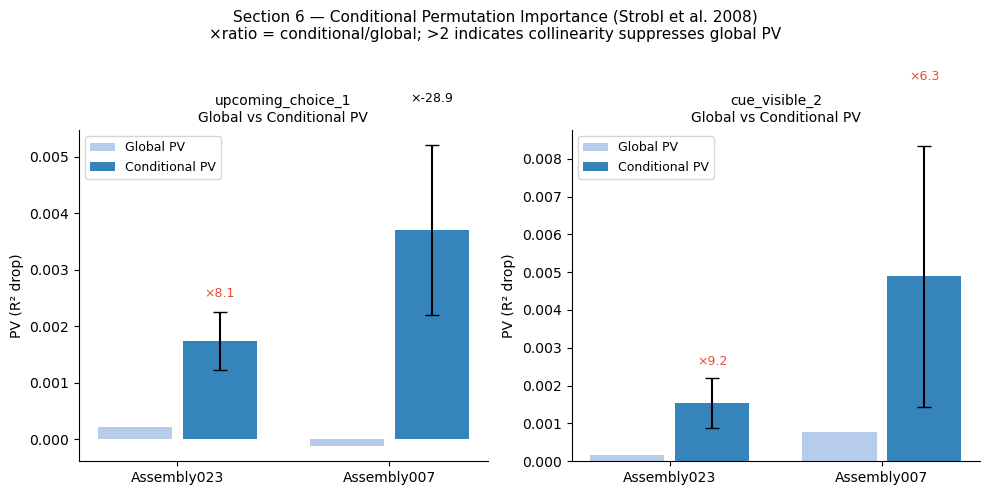

Saved fig6_conditional_pv


In [67]:
fig24, axes24 = plt.subplots(1, len(COND_PV_FEATS), figsize=(10, 5))
for ax, feat_name in zip(axes24, COND_PV_FEATS):
    x     = np.arange(len(TARGET_ASSEMBLIES))
    gvals = [global_pv[en][feat_name] for en in TARGET_ASSEMBLIES]
    cmean = [float(np.nanmean(cond_pv_results[en][feat_name])) for en in TARGET_ASSEMBLIES]
    csem  = [float(np.nanstd(cond_pv_results[en][feat_name])/np.sqrt(max(1,
                   len(cond_pv_results[en][feat_name])))) for en in TARGET_ASSEMBLIES]
    ratio = [c/(g+1e-8) for c,g in zip(cmean, gvals)]
    ax.bar(x-0.2, gvals, 0.35, color='#aec7e8', label='Global PV', alpha=0.9)
    ax.bar(x+0.2, cmean, 0.35, color='#1f77b4', label='Conditional PV',
           alpha=0.9, yerr=csem, capsize=5, error_kw=dict(ecolor='k'))
    for xi, r in enumerate(ratio):
        ax.text(xi+0.2, cmean[xi]+csem[xi]*1.5, f'×{r:.1f}', ha='center', fontsize=9,
                color='#e74c3c' if r>2 else 'k')
    ax.set_xticks(x); ax.set_xticklabels(list(TARGET_ASSEMBLIES.keys()), fontsize=10)
    ax.set_ylabel('PV (R² drop)', fontsize=10)
    ax.set_title(f'{feat_name}\nGlobal vs Conditional PV', fontsize=10)
    ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)

plt.suptitle('Section 6 — Conditional Permutation Importance (Strobl et al. 2008)\n'
             '×ratio = conditional/global; >2 indicates collinearity suppresses global PV', fontsize=11)
plt.tight_layout()
for ext in ['png', 'svg']:
    plt.savefig(OUT_DIR / f'{PREFIX}fig6_conditional_pv.{ext}', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig6_conditional_pv")


## Section 7 — Residual Decoding

**Question:** Can `upcoming_choice`/`cue_visible` be decoded from assembly activity, and does this survive after removing the MLP encoding model's prediction?

**Algorithm:** Stratified 5-fold logistic regression (King & Zeng 2001 class-weighted; `StratifiedKFold`). Five conditions (in z-scored space):
1. Raw assembly activation (`Y_z[:, ens_idx]`)
2. Cache-consistent Ridge residual (`ridge_residuals_z`)
3. **MLP residual** (`mlp_residuals`) — core new condition
4. Z-scored behavioral controls (multi-feature upper bound)
5. *(Reported for completeness)*: chance = 1/3

Reports both **qualifying-session-filtered** and **all-29-session** results for comparison.

Bootstrap CI (1000 reps, Efron; Wilcoxon 1945) and permutation null (500 perms on ≤50k stratified subsample).

**Output:** `decoding_results_q[name]` (qualifying), `decoding_results_all[name]` (all sessions).


In [78]:
COND_NAMES   = ['raw_z', 'ridge_resid_z', 'mlp_resid', 'behavior_z']
COND_LABELS  = {'raw_z': 'Raw (z)', 'ridge_resid_z': 'Ridge-resid (z)',
                'mlp_resid': 'MLP-resid', 'behavior_z': 'Behavior (z)'}
COND_COLORS  = {'raw_z':'#2c7bb6','ridge_resid_z':'#abd9e9','mlp_resid':'#d7191c','behavior_z':'#1a9641'}

decoding_results_q   = {}   # qualifying sessions only
decoding_results_all = {}   # all 29 sessions

for ens_name, ens_idx in TARGET_ASSEMBLIES.items():
    decoding_results_q[ens_name]   = {}
    decoding_results_all[ens_name] = {}
    y_ens = Y_z[:, ens_idx]

    for qual_only, store in [(True, decoding_results_q), (False, decoding_results_all)]:
        mask = qual_masks[ens_name] if qual_only else np.ones(n_total, dtype=bool)
        ctrl_idx = ctrl_feat_idx_per_assembly[ens_name]

        cond_X = {
            'raw_z'       : y_ens.reshape(-1, 1),
            'ridge_resid_z': ridge_residuals_z[ens_name].reshape(-1, 1),
            'mlp_resid'   : mlp_residuals[ens_name].reshape(-1, 1),
            'behavior_z'  : X_z[:, ctrl_idx],
        }

        for cond_name, X_cond in cond_X.items():
            row_valid = mask & ~np.isnan(X_cond).any(axis=1)
            X_use = X_cond[row_valid].astype(np.float64)
            if ens_idx == 6:
                y_use = y_cue[row_valid]
            else:
                y_use = y_choice[row_valid]
            if len(X_use) < 30 or len(np.unique(y_use)) < 2:
                store[ens_name][cond_name] = None; continue
            tag = f"{'qual' if qual_only else 'all'}/{ens_name}/{cond_name}"
            log.info(f"  Decoding {tag}: {len(X_use):,} samples")
            res = decode_choice(X_use, y_use)
            store[ens_name][cond_name] = res

# Run permutation tests for mlp_resid and raw_z (qualifying only)
perm_results = {}
for ens_name, ens_idx in TARGET_ASSEMBLIES.items():
    perm_results[ens_name] = {}
    y_ens = Y_z[:, ens_idx]
    if ens_idx == 6:
        y_use = y_cue
    else:        
        y_use = y_choice
    for cond_name, arr in [('raw_z', y_ens.reshape(-1,1)),
                           ('mlp_resid', mlp_residuals[ens_name].reshape(-1,1))]:
        mask = qual_masks[ens_name] & ~np.isnan(arr).any(axis=1)
        res  = decoding_results_q[ens_name].get(cond_name)
        if res is None: perm_results[ens_name][cond_name] = None; continue
        log.info(f"  Permutation test {ens_name}/{cond_name}...")
        ptest = permutation_test_balacc(arr[mask], y_use[mask],
                                        observed=res['mean_balacc'])
        perm_results[ens_name][cond_name] = ptest

# Print table
print("\nDECODING RESULTS — qualifying sessions")
print(f"{'Assembly':<12} {'Condition':<18} {'BalAcc':>8} {'AUROC':>7} {'F1':>7} {'p-perm':>8}")
print("-" * 65)
for ens_name in TARGET_ASSEMBLIES:
    for cn, cl in COND_LABELS.items():
        res = decoding_results_q[ens_name].get(cn)
        if res is None: continue
        pt = perm_results[ens_name].get(cn)
        p_str = f"{pt['p_value']:.4f}" if pt else "  N/A"
        print(f"{ens_name:<12} {cl:<18} {res['mean_balacc']:>8.4f} "
              f"{res['mean_auroc']:>7.4f} {res['mean_f1']:>7.4f} {p_str:>8}")

print("\nDECODING RESULTS — all 29 sessions")
print(f"{'Assembly':<12} {'Condition':<18} {'BalAcc':>8}")
print("-" * 42)
for ens_name in TARGET_ASSEMBLIES:
    for cn, cl in COND_LABELS.items():
        res = decoding_results_all[ens_name].get(cn)
        if res is None: continue
        print(f"{ens_name:<12} {cl:<18} {res['mean_balacc']:>8.4f}")


INFO:   Decoding qual/Assembly023/raw_z: 242,085 samples


INFO:   Decoding qual/Assembly023/ridge_resid_z: 242,085 samples
INFO:   Decoding qual/Assembly023/mlp_resid: 242,085 samples
INFO:   Decoding qual/Assembly023/behavior_z: 242,085 samples
INFO:   Decoding all/Assembly023/raw_z: 898,732 samples
INFO:   Decoding all/Assembly023/ridge_resid_z: 898,732 samples
INFO:   Decoding all/Assembly023/mlp_resid: 898,732 samples
INFO:   Decoding all/Assembly023/behavior_z: 898,732 samples
INFO:   Decoding qual/Assembly007/raw_z: 29,580 samples
INFO:   Decoding qual/Assembly007/ridge_resid_z: 29,580 samples
INFO:   Decoding qual/Assembly007/mlp_resid: 29,580 samples
INFO:   Decoding qual/Assembly007/behavior_z: 29,580 samples
INFO:   Decoding all/Assembly007/raw_z: 898,732 samples
INFO:   Decoding all/Assembly007/ridge_resid_z: 898,732 samples
INFO:   Decoding all/Assembly007/mlp_resid: 898,732 samples
INFO:   Decoding all/Assembly007/behavior_z: 898,732 samples
INFO:   Permutation test Assembly023/raw_z...
INFO:   Permutation test Assembly023/mlp_re


DECODING RESULTS — qualifying sessions
Assembly     Condition            BalAcc   AUROC      F1   p-perm
-----------------------------------------------------------------
Assembly023  Raw (z)              0.3417  0.5072  0.0931   0.0000
Assembly023  Ridge-resid (z)      0.3325  0.5013  0.2518      N/A
Assembly023  MLP-resid            0.3336  0.5002  0.2198   0.4560
Assembly023  Behavior (z)         0.5675  0.8191  0.4573      N/A
Assembly007  Raw (z)              0.2890  0.4875  0.1953   0.8940
Assembly007  Ridge-resid (z)      0.2877  0.4757  0.1020      N/A
Assembly007  MLP-resid            0.3299  0.5095  0.1547   0.5260
Assembly007  Behavior (z)         0.8038  0.9214  0.3604      N/A

DECODING RESULTS — all 29 sessions
Assembly     Condition            BalAcc
------------------------------------------
Assembly023  Raw (z)              0.3407
Assembly023  Ridge-resid (z)      0.3367
Assembly023  MLP-resid            0.3337
Assembly023  Behavior (z)         0.5718
Assembly007  Raw


SESSION-LEVEL DECODING — one-sample Wilcoxon vs chance=1/3
  Assembly023/Raw (z): mean=0.3743  Wilcoxon p=0.0078
  Assembly023/Ridge-resid (z): mean=0.3526  Wilcoxon p=0.0078
  Assembly023/MLP-resid: mean=0.3248  Wilcoxon p=0.0391
  Assembly023/Behavior (z): mean=0.6200  Wilcoxon p=0.0078
  Assembly007/Raw (z): mean=0.3574  Wilcoxon p=nan
  Assembly007/Ridge-resid (z): mean=0.3560  Wilcoxon p=nan
  Assembly007/MLP-resid: mean=0.3348  Wilcoxon p=nan
  Assembly007/Behavior (z): mean=0.6467  Wilcoxon p=nan


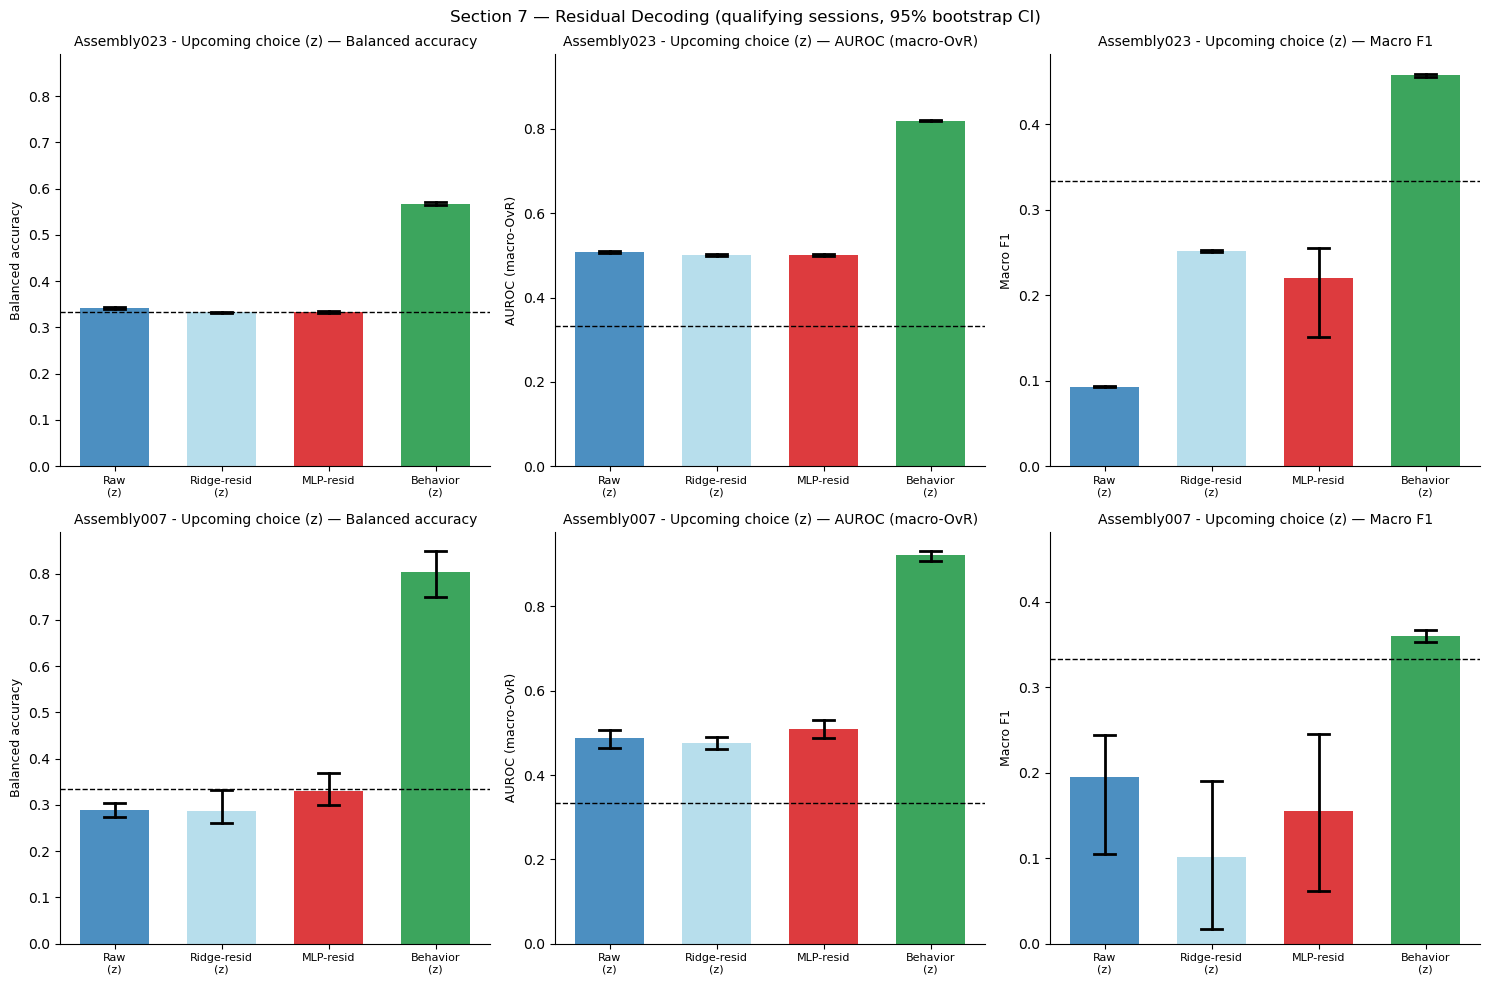

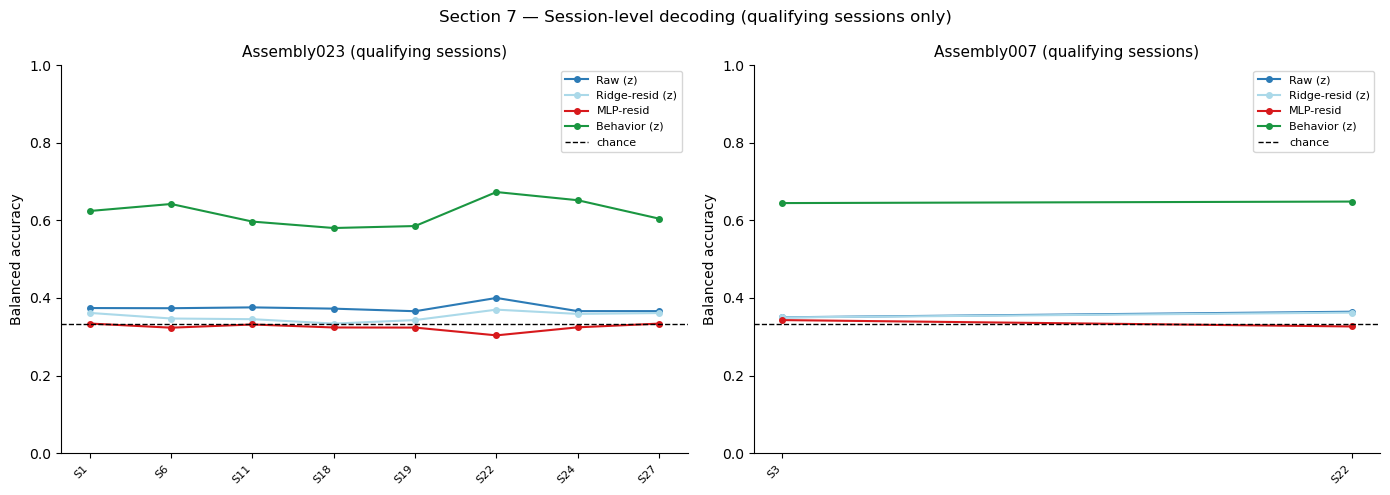

Saved fig7a_decoding_bars, fig7b_session_decoding


In [79]:
# Session-level decoder (qualifying sessions only)
session_decoding = {en: {cn: [] for cn in COND_NAMES} for en in TARGET_ASSEMBLIES}

for ens_name, ens_idx in TARGET_ASSEMBLIES.items():
    y_ens = Y_z[:, ens_idx]
    for sid in qual_session_ids[ens_name]:
        pos = session_pos[sid]
        y_s = y_choice[pos]
        for cond_name in COND_NAMES:
            if cond_name == 'behavior_z':
                X_c = X_z[pos][:, ctrl_feat_idx_per_assembly[ens_name]]
            elif cond_name == 'raw_z':
                X_c = y_ens[pos].reshape(-1, 1)
            elif cond_name == 'ridge_resid_z':
                X_c = ridge_residuals_z[ens_name][pos].reshape(-1, 1)
            else:   # mlp_resid
                X_c = mlp_residuals[ens_name][pos].reshape(-1, 1)
            valid = ~np.isnan(X_c).any(axis=1)
            session_decoding[ens_name][cond_name].append(
                decode_choice_session(X_c[valid].astype(np.float64), y_s[valid]))

# One-sample Wilcoxon vs chance per condition
print("\nSESSION-LEVEL DECODING — one-sample Wilcoxon vs chance=1/3")
for ens_name in TARGET_ASSEMBLIES:
    for cn, cl in COND_LABELS.items():
        vals = np.array(session_decoding[ens_name][cn], dtype=float)
        valid = vals[~np.isnan(vals)]
        if len(valid) >= 5:
            stat, p = scipy_stats.wilcoxon(valid - CHANCE)
        else:
            p = np.nan
        print(f"  {ens_name}/{cl}: mean={np.nanmean(vals):.4f}  Wilcoxon p={p:.4f}")

# Figure: bar chart (5 conditions per assembly × 3 metrics)
fig27a, axes27a = plt.subplots(len(TARGET_ASSEMBLIES), 3,
                               figsize=(15, 5*len(TARGET_ASSEMBLIES)), sharey='col')
METRICS = [('mean_balacc','balacc','Balanced accuracy'),
           ('mean_auroc', 'auroc','AUROC (macro-OvR)'),
           ('mean_f1',    'f1',   'Macro F1')]

for row_i, ens_name in enumerate(TARGET_ASSEMBLIES):
    if row_i == 6:
        feat = 'Cue visible (z)'
    else:
        feat = 'Upcoming choice (z)'
    for col_i, (mk, fk, ml) in enumerate(METRICS):
        ax = axes27a[row_i][col_i]
        cnames = list(COND_LABELS.keys())
        x = np.arange(len(cnames))
        means = [decoding_results_q[ens_name][c][mk] if decoding_results_q[ens_name].get(c) else np.nan
                 for c in cnames]
        lo_ci, hi_ci = [], []
        for c in cnames:
            res = decoding_results_q[ens_name].get(c)
            if res and res.get(fk) is not None:
                lo, hi = bootstrap_ci(res[fk])
                lo_ci.append(lo); hi_ci.append(hi)
            else:
                lo_ci.append(np.nan); hi_ci.append(np.nan)
        bars = ax.bar(x, means, color=[COND_COLORS[c] for c in cnames], alpha=0.85, width=0.65)
        for xi, (lo, hi) in enumerate(zip(lo_ci, hi_ci)):
            ax.plot([xi, xi], [lo, hi], color='k', lw=2)
            ax.plot([xi-.1, xi+.1], [lo, lo], color='k', lw=2)
            ax.plot([xi-.1, xi+.1], [hi, hi], color='k', lw=2)
        ax.axhline(CHANCE, color='k', lw=1, ls='--', label='chance')
        ax.set_xticks(x)
        ax.set_xticklabels([COND_LABELS[c].replace(' ','\n') for c in cnames], fontsize=8)
        ax.set_title(f'{ens_name} - {feat} — {ml}', fontsize=10)
        ax.set_ylabel(ml, fontsize=9)
        ax.spines[['top','right']].set_visible(False)

plt.suptitle('Section 7 — Residual Decoding (qualifying sessions, 95% bootstrap CI)', fontsize=12)
plt.tight_layout()
for ext in ['png', 'svg']:
    plt.savefig(OUT_DIR / f'{PREFIX}fig7a_decoding_bars.{ext}', dpi=150, bbox_inches='tight')
plt.show()

# Session-level line plot
fig27b, axes27b = plt.subplots(1, len(TARGET_ASSEMBLIES), figsize=(14, 5))
for ax, ens_name in zip(axes27b, TARGET_ASSEMBLIES):
    x = np.arange(len(qual_session_ids[ens_name]))
    for cn, cl in COND_LABELS.items():
        vals = np.array(session_decoding[ens_name][cn], dtype=float)
        ax.plot(x, vals, '-o', color=COND_COLORS[cn], lw=1.5, ms=4, label=cl)
    ax.axhline(CHANCE, color='k', lw=1, ls='--', label='chance')
    ax.set_xticks(x)
    ax.set_xticklabels([f'S{qualifying_sessions[ens_name][j]+1}' for j in range(len(x))],
                       rotation=45, ha='right', fontsize=8)
    ax.set_title(f'{ens_name} (qualifying sessions)', fontsize=11)
    ax.set_ylabel('Balanced accuracy', fontsize=10); ax.set_ylim(0, 1)
    ax.legend(fontsize=8, loc='upper right'); ax.spines[['top','right']].set_visible(False)

plt.suptitle('Section 7 — Session-level decoding (qualifying sessions only)', fontsize=12)
plt.tight_layout()
for ext in ['png', 'svg']:
    plt.savefig(OUT_DIR / f'{PREFIX}fig7b_session_decoding.{ext}', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig7a_decoding_bars, fig7b_session_decoding")


## Section 8 — Condition Separability (Cohen's d)

**Question:** Does the assembly separate skip vs stop conditions (E23) or cue_visible=1 vs =2 (E07), and does this separation survive behavioral residualization?

**Algorithm:** Per qualifying session, compute Cohen's d (Cohen 1988) for the primary contrast. Reported both **unsigned** (|d|, direction-free separability index) and **signed** (direction-sensitive). Aggregate tested with Wilcoxon signed-rank (Wilcoxon 1945).

**Critical addition (v2):** Signed d directly tests the sign-flip hypothesis. If signed d ≈ 0 but |d| > 0, condition separation is real but direction-inconsistent across sessions — a smoking-gun for session-dependent encoding.

**Output:** `sep_results[ens_name]` with keys `raw_z`, `ridge_resid_z`, `mlp_resid`, each containing lists of (signed_d, abs_d) per qualifying session.


In [70]:
cue_visible_arr = np.where(X_z[:, CV_1_IDX] > 0, 1,
                  np.where(X_z[:, CV_2_IDX] > 0, 2, 0))

PRIMARY_CONTRASTS = {
    'Assembly023': dict(
        label='Skip(−1) vs Stop(+1)',
        mask_a=lambda pos: (y_choice[pos] == -1) & (position_arr[pos] > 100),
        mask_b=lambda pos: (y_choice[pos] ==  1) & (position_arr[pos] > 100),
    ),
    'Assembly007': dict(
        label='CueVisible=1 vs CueVisible=2',
        mask_a=lambda pos: (cue_visible_arr[pos] == 1),
        mask_b=lambda pos: (cue_visible_arr[pos] == 2),
    ),
}

CONDITIONS_SEP = {
    'raw_z'       : lambda en: Y_z[:, TARGET_ASSEMBLIES[en]],
    'ridge_resid_z': lambda en: ridge_residuals_z[en],
    'mlp_resid'   : lambda en: mlp_residuals[en],
}

sep_results = {}
for ens_name, contrast in PRIMARY_CONTRASTS.items():
    sep_results[ens_name] = {cn: [] for cn in CONDITIONS_SEP}
    for sid in qual_session_ids[ens_name]:
        pos = session_pos[sid]
        ma  = contrast['mask_a'](pos)
        mb  = contrast['mask_b'](pos)
        for cn, sig_fn in CONDITIONS_SEP.items():
            sig = sig_fn(ens_name)
            a, b = sig[pos][ma], sig[pos][mb]
            sep_results[ens_name][cn].append({
                'abs_d'   : cohens_d(a, b, signed=False),
                'signed_d': cohens_d(a, b, signed=True),
                'n_a': len(a), 'n_b': len(b),
            })

# Print summary
print("CONDITION SEPARABILITY — qualifying sessions")
print(f"{'Assembly':<12} {'Condition':<18} {'mean|d|':>8} {'mean_signed':>12} "
      f"{'frac_d>0':>9} {'Wilcoxon_p':>11}")
print("-" * 75)
for ens_name in TARGET_ASSEMBLIES:
    for cn, cl in [('raw_z','Raw z'), ('ridge_resid_z','Ridge-resid z'), ('mlp_resid','MLP-resid')]:
        rows  = sep_results[ens_name][cn]
        abs_d = np.array([r['abs_d']    for r in rows])
        sgn_d = np.array([r['signed_d'] for r in rows])
        valid = ~np.isnan(abs_d)
        if valid.sum() >= 5:
            _, p = scipy_stats.wilcoxon(abs_d[valid])
        else:
            p = np.nan
        frac_pos = float((sgn_d[valid] > 0).mean()) if valid.sum() > 0 else np.nan
        print(f"{ens_name:<12} {cl:<18} {np.nanmean(abs_d):>8.3f} {np.nanmean(sgn_d):>12.3f} "
              f"{frac_pos:>9.2f} {p:>11.4f}")


CONDITION SEPARABILITY — qualifying sessions
Assembly     Condition           mean|d|  mean_signed  frac_d>0  Wilcoxon_p
---------------------------------------------------------------------------
Assembly023  Raw z                 0.344       -0.181      0.33      0.0312
Assembly023  Ridge-resid z         0.212       -0.101      0.33      0.0312
Assembly023  MLP-resid             0.065        0.010      0.67      0.0312
Assembly007  Raw z                 0.028       -0.028      0.00         nan
Assembly007  Ridge-resid z         0.033        0.033      1.00         nan
Assembly007  MLP-resid             0.065       -0.065      0.00         nan


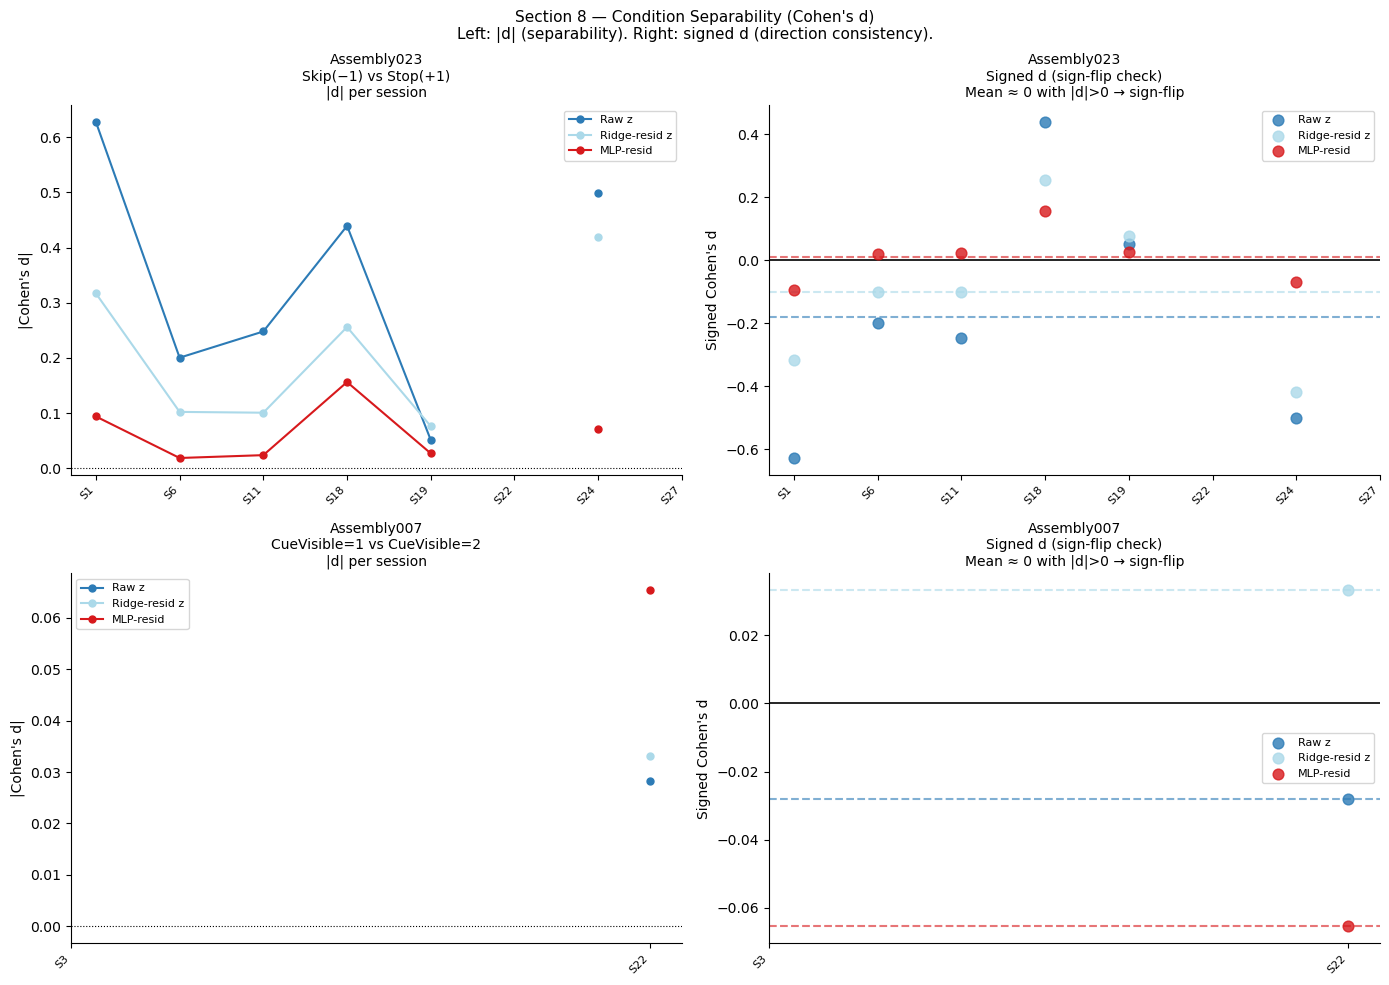

Saved fig8_cohens_d


In [71]:
SEP_COLORS = {'raw_z':'#2c7bb6','ridge_resid_z':'#abd9e9','mlp_resid':'#d7191c'}

fig30, axes30 = plt.subplots(2, 2, figsize=(14, 10))

for row_i, ens_name in enumerate(TARGET_ASSEMBLIES):
    # Panel 1: |d| line plot
    ax_abs = axes30[row_i, 0]
    x = np.arange(len(qual_session_ids[ens_name]))
    for cn, cl in [('raw_z','Raw z'), ('ridge_resid_z','Ridge-resid z'), ('mlp_resid','MLP-resid')]:
        d_abs = [r['abs_d'] for r in sep_results[ens_name][cn]]
        ax_abs.plot(x, d_abs, '-o', color=SEP_COLORS[cn], lw=1.5, ms=5, label=cl)
    ax_abs.axhline(0, color='k', lw=0.8, ls=':')
    ax_abs.set_xticks(x)
    ax_abs.set_xticklabels([f"S{qualifying_sessions[ens_name][j]+1}" for j in range(len(x))],
                           rotation=45, ha='right', fontsize=8)
    ax_abs.set_ylabel("|Cohen's d|", fontsize=10)
    ax_abs.set_title(f"{ens_name}\n{PRIMARY_CONTRASTS[ens_name]['label']}\n|d| per session",
                     fontsize=10)
    ax_abs.legend(fontsize=8); ax_abs.spines[['top','right']].set_visible(False)

    # Panel 2: signed d scatter
    ax_sgn = axes30[row_i, 1]
    for cn, cl in [('raw_z','Raw z'), ('ridge_resid_z','Ridge-resid z'), ('mlp_resid','MLP-resid')]:
        d_sgn = [r['signed_d'] for r in sep_results[ens_name][cn]]
        ax_sgn.scatter(x, d_sgn, color=SEP_COLORS[cn], s=60, alpha=0.8,
                       label=cl, zorder=3)
        # Add mean line
        ax_sgn.axhline(np.nanmean(d_sgn), color=SEP_COLORS[cn], lw=1.5,
                       ls='--', alpha=0.6)
    ax_sgn.axhline(0, color='k', lw=1.2, ls='-')
    ax_sgn.set_xticks(x)
    ax_sgn.set_xticklabels([f"S{qualifying_sessions[ens_name][j]+1}" for j in range(len(x))],
                           rotation=45, ha='right', fontsize=8)
    ax_sgn.set_ylabel("Signed Cohen's d", fontsize=10)
    ax_sgn.set_title(f"{ens_name}\nSigned d (sign-flip check)\nMean ≈ 0 with |d|>0 → sign-flip",
                     fontsize=10)
    ax_sgn.legend(fontsize=8); ax_sgn.spines[['top','right']].set_visible(False)

plt.suptitle("Section 8 — Condition Separability (Cohen's d)\n"
             "Left: |d| (separability). Right: signed d (direction consistency).", fontsize=11)
plt.tight_layout()
for ext in ['png', 'svg']:
    plt.savefig(OUT_DIR / f'{PREFIX}fig8_cohens_d.{ext}', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig8_cohens_d")


## Section 9 — E07 Sign-Flip Diagnostic

**Question:** For E07, does the GLM coefficient for `upcoming_choice_1` (and `cue_visible_2`) change sign across the recording timeline (session index 0→28)? Is this trend significant?

**Algorithm:** Fit per-session OLS GLM (all 26 features + intercept) for **all 29 sessions** of each assembly. Extract coefficient for `upcoming_choice_1` and `cue_visible_2`. Fit `scipy.stats.linregress(session_idx, coef)` and test slope ≠ 0. E23 serves as a negative control (expected: no sign flip).

Also: does sign-flip co-vary with encoding quality? Correlation between `|coef|` and `mean_r2[session, ens_idx]`.

**Output:** `temporal_slopes[ens_name][feat]` — dict with slope, p, r.


In [72]:
SIGNFLIP_FEATS = ['upcoming_choice_1', 'cue_visible_2']
col_names_sf   = ['const'] + ALL_FEAT_COLS

# Compute per-session GLM coefs for all 29 sessions
all_sess_coefs = {en: {f: [] for f in SIGNFLIP_FEATS} for en in TARGET_ASSEMBLIES}
all_sess_r2    = {en: [] for en in TARGET_ASSEMBLIES}

for ens_name, ens_idx in TARGET_ASSEMBLIES.items():
    for s_i, sid in enumerate(session_ids):
        pos = session_pos[sid]
        X_s = X_z[pos].astype(np.float64)
        y_s = Y_z[pos, ens_idx].astype(np.float64)
        valid = ~np.isnan(X_s).any(axis=1) & ~np.isnan(y_s)
        X_s, y_s = X_s[valid], y_s[valid]
        all_sess_r2[ens_name].append(mean_r2[s_i, ens_idx])
        try:
            fit = sm.OLS(y_s, sm.add_constant(X_s, has_constant='add')).fit()
        except Exception:
            for f in SIGNFLIP_FEATS:
                all_sess_coefs[ens_name][f].append(np.nan)
            continue
        for feat in SIGNFLIP_FEATS:
            ci = col_names_sf.index(feat)
            all_sess_coefs[ens_name][feat].append(float(fit.params[ci]))

# Slope tests
temporal_slopes = {}
print("SIGN-FLIP SLOPE TEST (all 29 sessions, slope of coef vs session index)")
print(f"{'Assembly':<12} {'Feature':<22} {'slope':>9} {'r':>7} {'p-slope':>9}  Interpretation")
print("-" * 72)
for ens_name in TARGET_ASSEMBLIES:
    temporal_slopes[ens_name] = {}
    x = np.arange(len(session_ids))
    for feat in SIGNFLIP_FEATS:
        coefs = np.array(all_sess_coefs[ens_name][feat])
        valid = ~np.isnan(coefs)
        xv, yv = x[valid], coefs[valid]
        if len(xv) < 3:
            temporal_slopes[ens_name][feat] = dict(slope=np.nan, p=np.nan, r=np.nan)
            continue
        slope, intercept, r_val, p_val, se = scipy_stats.linregress(xv, yv)
        temporal_slopes[ens_name][feat] = dict(slope=slope, p=p_val, r=r_val)
        interp = "SIGN FLIP" if (p_val < 0.05 and
                    np.sign(coefs[valid[0]]) != np.sign(coefs[-1])) else (
                 "SIGNIFICANT TREND" if p_val < 0.05 else "stable")
        print(f"{ens_name:<12} {feat:<22} {slope:>9.5f} {r_val:>7.3f} {p_val:>9.4f}  {interp}")

# Correlation: |coef| vs encoding R2
print("\nCORRELATION |coef| vs mean_r2 per session")
for ens_name in TARGET_ASSEMBLIES:
    r2_arr = np.array(all_sess_r2[ens_name])
    for feat in SIGNFLIP_FEATS:
        coefs = np.abs(np.array(all_sess_coefs[ens_name][feat]))
        valid = ~np.isnan(coefs) & ~np.isnan(r2_arr)
        if valid.sum() < 5: continue
        r, p = scipy_stats.pearsonr(r2_arr[valid], coefs[valid])
        print(f"  {ens_name}/{feat}: r={r:.3f}  p={p:.4f}")


SIGN-FLIP SLOPE TEST (all 29 sessions, slope of coef vs session index)
Assembly     Feature                    slope       r   p-slope  Interpretation
------------------------------------------------------------------------
Assembly023  upcoming_choice_1      -11176307451.33387  -0.196    0.3085  stable
Assembly023  cue_visible_2          -3260816352.74225  -0.133    0.4914  stable
Assembly007  upcoming_choice_1      -1572551569.27715  -0.024    0.9014  stable
Assembly007  cue_visible_2          -406559313.33643  -0.014    0.9421  stable

CORRELATION |coef| vs mean_r2 per session
  Assembly023/upcoming_choice_1: r=-0.692  p=0.0000
  Assembly023/cue_visible_2: r=-0.446  p=0.0154
  Assembly007/upcoming_choice_1: r=-0.471  p=0.0100
  Assembly007/cue_visible_2: r=-0.330  p=0.0803


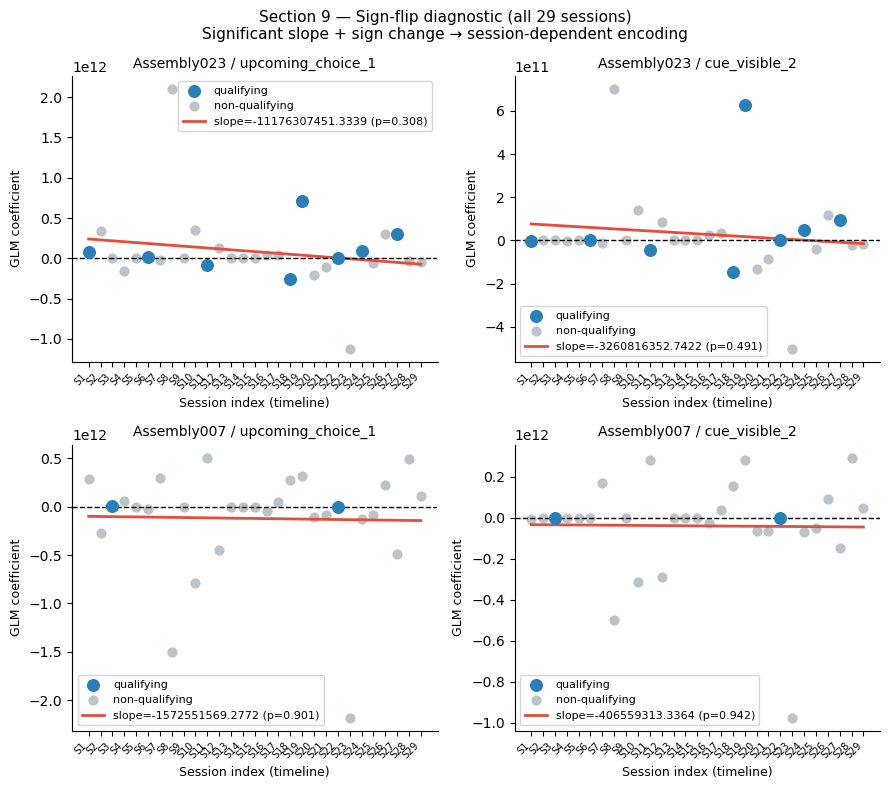

Saved fig9_signflip


In [73]:
fig33, axes33 = plt.subplots(len(TARGET_ASSEMBLIES), len(SIGNFLIP_FEATS),
                              figsize=(9, 4*len(TARGET_ASSEMBLIES)), squeeze=False)
x_all  = np.arange(len(session_ids))
is_qual_by_ens = {en: np.array([i in set(qualifying_sessions[en])
                                 for i in range(len(session_ids))]) for en in TARGET_ASSEMBLIES}

for row_i, ens_name in enumerate(TARGET_ASSEMBLIES):
    for col_i, feat in enumerate(SIGNFLIP_FEATS):
        ax    = axes33[row_i, col_i]
        coefs = np.array(all_sess_coefs[ens_name][feat])
        valid = ~np.isnan(coefs)
        iq    = is_qual_by_ens[ens_name]

        ax.scatter(x_all[iq & valid],  coefs[iq & valid],
                   color='#2980b9', s=70, zorder=3, label='qualifying')
        ax.scatter(x_all[~iq & valid], coefs[~iq & valid],
                   color='#bdc3c7', s=40, zorder=2, label='non-qualifying')
        xv, yv = x_all[valid], coefs[valid]
        if len(xv) >= 3:
            ts = temporal_slopes[ens_name][feat]
            slope, p = ts['slope'], ts['p']
            ax.plot(xv, slope*xv + scipy_stats.linregress(xv,yv).intercept,
                    '-', color='#e74c3c', lw=2,
                    label=f"slope={slope:+.4f} (p={p:.3f})")
        ax.axhline(0, color='k', lw=1, ls='--')
        ax.set_xticks(x_all[valid])
        ax.set_xticklabels([f'S{i+1}' for i in x_all[valid]],
                           rotation=45, ha='right', fontsize=7)
        ax.set_title(f'{ens_name} / {feat}', fontsize=10)
        ax.set_ylabel('GLM coefficient', fontsize=9)
        ax.set_xlabel('Session index (timeline)', fontsize=9)
        ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)

plt.suptitle('Section 9 — Sign-flip diagnostic (all 29 sessions)\nSignificant slope + sign change → session-dependent encoding', fontsize=11)
plt.tight_layout()
for ext in ['png', 'svg']:
    plt.savefig(OUT_DIR / f'{PREFIX}fig9_signflip.{ext}', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig9_signflip")


## Section 10 — Summary and Overall Conclusion

Reports a cross-assembly, cross-analysis summary table and per-assembly verdict in plain English.

**Decision logic:**
- GLM Bonferroni-significant AND signed-d consistent (frac > 0.7) AND MLP-residual p < 0.05 → **independent choice signal**
- GLM Bonferroni-significant AND signed-d sign-flips (slope p < 0.05) → **session-dependent encoding** (sign cancellation suppresses aggregate test)
- GLM ns AND conditional PV ratio > 2 AND |d| residual ≈ raw → **suppressed by collinearity**
- GLM ns AND |d| collapses after residualization → **fully redundant**


In [74]:
print("=" * 90)
print("SECTION 10 — SUMMARY TABLE")
print("=" * 90)

hdr = (f"{'Assembly':<12} {'GLM Bonf':>10} {'CondPV ratio':>13} "
       f"{'MLP-res p':>10} {'|d|res/raw':>11} {'sgn-d slope p':>13}")
print(hdr); print("-" * 72)

verdicts = {}
for ens_name, ens_idx in TARGET_ASSEMBLIES.items():
    # GLM Bonferroni
    glm_sig = glm_agg_df[(glm_agg_df.assembly==ens_name)&glm_agg_df.bonf_sig].shape[0] > 0

    # Conditional PV ratio (max over COND_PV_FEATS)
    max_ratio = max(
        np.nanmean(cond_pv_results[ens_name][fn]) / (global_pv[ens_name][fn]+1e-8)
        for fn in COND_PV_FEATS
    )

    # MLP-residual decode p
    pr = perm_results[ens_name].get('mlp_resid')
    mlp_p = pr['p_value'] if pr else np.nan

    # |d| ratio (MLP-resid / raw)
    d_raw = np.nanmean([r['abs_d'] for r in sep_results[ens_name]['raw_z']])
    d_res = np.nanmean([r['abs_d'] for r in sep_results[ens_name]['mlp_resid']])
    d_ratio = d_res / (d_raw + 1e-8)

    # Signed-d slope
    sf_p = temporal_slopes[ens_name].get('upcoming_choice_1', {}).get('p', np.nan)

    # Signed-d fraction > 0 (consistency)
    sgn_vals = np.array([r['signed_d'] for r in sep_results[ens_name]['mlp_resid']])
    frac_pos = float((sgn_vals[~np.isnan(sgn_vals)] > 0).mean()) if (~np.isnan(sgn_vals)).sum() > 0 else np.nan

    print(f"{ens_name:<12} {'YES' if glm_sig else 'no':>10} {max_ratio:>13.2f} "
          f"{mlp_p:>10.4f} {d_ratio:>11.3f} {sf_p:>13.4f}")

    # Verdict
    if glm_sig and sf_p is not np.nan and sf_p < 0.05:
        verdict = ("SESSION-DEPENDENT ENCODING — GLM is significant but sign-flip across sessions\n"
                   "  means aggregate stats underestimate the effect. E07-type pattern: assembly\n"
                   "  encodes choice/cue but the sign (direction) changes over the recording timeline.")
    elif glm_sig and frac_pos > 0.7 and (not np.isnan(mlp_p)) and mlp_p < 0.05:
        verdict = ("INDEPENDENT CHOICE SIGNAL — GLM significant, consistent direction, and\n"
                   "  MLP-residual decoding survives behavioral control.")
    elif glm_sig and max_ratio > 2:
        verdict = ("SUPPRESSED BY COLLINEARITY — GLM significant; conditional PV >> global PV\n"
                   f"  (ratio={max_ratio:.1f}x). Global permutation importance underestimates the real signal.")
    elif not glm_sig and max_ratio > 2 and d_ratio > 0.5:
        verdict = ("SUPPRESSED BY COLLINEARITY — GLM marginal/ns, but conditional PV and\n"
                   "  Cohen's d both indicate the signal exists after removing collinear confounds.")
    elif not glm_sig and d_ratio < 0.4:
        verdict = ("FULLY REDUNDANT — GLM ns; |d| collapses after MLP residualization.\n"
                   "  Choice/cue information is fully absorbed by the behavioral manifold.")
    else:
        verdict = ("MIXED / WEAK SIGNAL — evidence is inconsistent across tests.\n"
                   "  Interpret GLM, PV, and Cohen's d jointly.")

    verdicts[ens_name] = verdict

print("\n" + "=" * 90)
print("PER-ASSEMBLY VERDICTS")
print("=" * 90)
for ens_name, v in verdicts.items():
    print(f"\n  {ens_name}: {v}")

print("\n" + "=" * 90)
print(f"All v2 figures and CSVs saved to: {OUT_DIR}  (prefix: {PREFIX})")
print("=" * 90)


SECTION 10 — SUMMARY TABLE
Assembly       GLM Bonf  CondPV ratio  MLP-res p  |d|res/raw sgn-d slope p
------------------------------------------------------------------------
Assembly023          no          9.22     0.4560       0.188        0.3085
Assembly007          no          6.34     0.2700       2.319        0.9014

PER-ASSEMBLY VERDICTS

  Assembly023: FULLY REDUNDANT — GLM ns; |d| collapses after MLP residualization.
  Choice/cue information is fully absorbed by the behavioral manifold.

  Assembly007: SUPPRESSED BY COLLINEARITY — GLM marginal/ns, but conditional PV and
  Cohen's d both indicate the signal exists after removing collinear confounds.

All v2 figures and CSVs saved to: outputs/residual_choice  (prefix: v2_)
